# MF34 Covariance Heatmap Plotting Examples

This notebook demonstrates various use cases for plotting covariance heatmaps from MF34 data using the `HeatmapBuilder` class.

In [30]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt

# Import KIKA modules
from kika.endf import read_endf
from kika.plotting import HeatmapBuilder
from kika.cov.mf34_covmat import MF34CovMat

## Load MF34 Covariance Data

Load the ENDF file containing MF34 covariance data for Fe-56.

In [31]:
# Load the ENDF file with MF34 data
endf_file = "/share_snc/snc/JuanMonleon/jeff40_with_MF4_from_jeff33/26-Fe-56g.txt"
endf = read_endf(endf_file, mf_numbers=34)

print(f"Loaded ENDF file: {endf_file}")
print(f"Material (MAT): {endf.mat}")
print(f"ZAID: {endf.zaid}")
print(f"Isotope: {endf.isotope}")
print(f"Available MF sections: {sorted(endf.files.keys())}")

Loaded ENDF file: /share_snc/snc/JuanMonleon/jeff40_with_MF4_from_jeff33/26-Fe-56g.txt
Material (MAT): None
ZAID: None
Isotope: None
Available MF sections: [34]


## Check Available MF34 Data

Explore what covariance data is available in MF34.

## Alternative: Direct Loading with MF34CovMat.from_endf()

You can also load MF34 data directly using the convenience class method:

In [32]:
# Check if MF34 exists and convert to MF34CovMat
if 34 in endf.files:
    mf34 = endf.files[34]
    print(f"MF34 available MT sections: {sorted(mf34.sections.keys())}")
    
    # Convert MF34 to MF34CovMat object for easier manipulation
    mf34_covmat = mf34.to_ang_covmat(energy_unit='eV')
    print(f"\nMF34CovMat created successfully")
    print(f"Number of covariance matrices: {mf34_covmat.num_matrices}")
    
    # Show summary
    print("\nSummary of available data:")
    print(mf34_covmat.summary().head(10))
else:
    print("MF34 not available in this file")

MF34 available MT sections: [2]

MF34CovMat created successfully
Number of covariance matrices: 21

Summary of available data:
   isotope_row  MT_row  L_row  isotope_col  MT_col  L_col  NE  is_relative  \
0        26056       2      1        26056       2      1  43         True   
1        26056       2      1        26056       2      2  16         True   
2        26056       2      1        26056       2      3  16         True   
3        26056       2      1        26056       2      4  16         True   
4        26056       2      1        26056       2      5  13         True   
5        26056       2      1        26056       2      6  13         True   
6        26056       2      2        26056       2      2  43         True   
7        26056       2      2        26056       2      3  16         True   
8        26056       2      2        26056       2      4  16         True   
9        26056       2      2        26056       2      5  13         True   

         frame

## Example 1: Basic Heatmap with Default Settings

Create a simple heatmap with all default settings. The default title from the data will be used.

Creating heatmap for MT=2, L=1, Isotope=26056


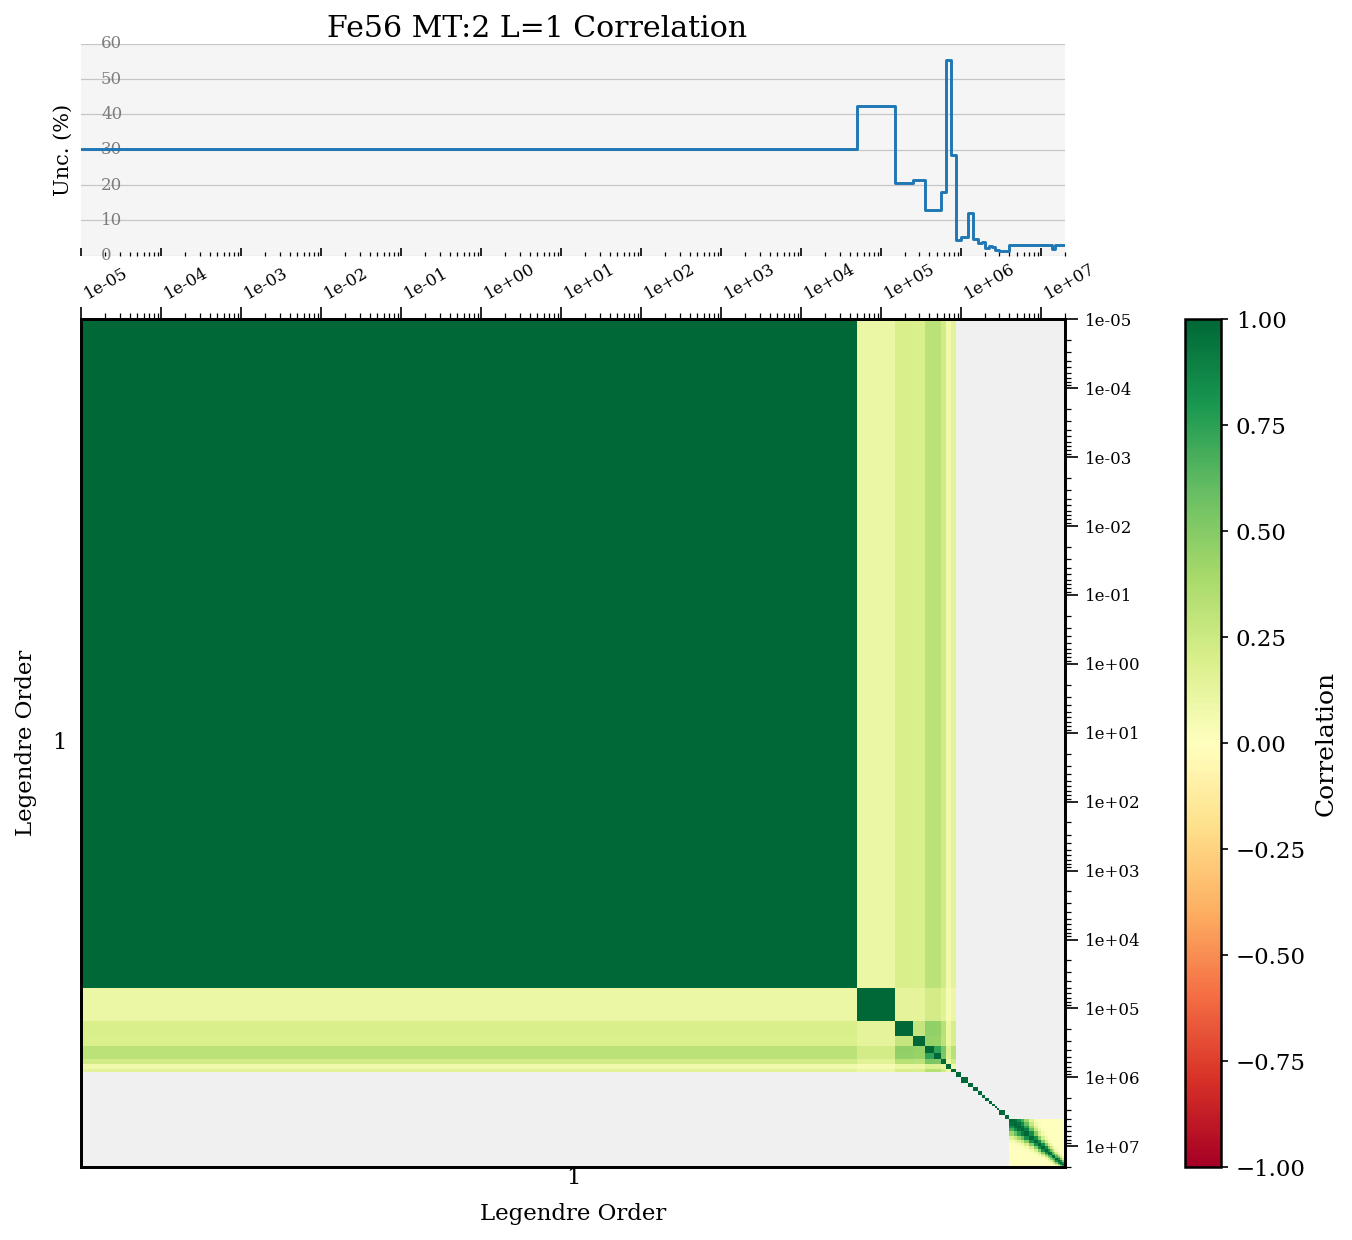

In [33]:
# Get heatmap data for a specific MT reaction and Legendre coefficient
# First, let's pick an MT and Legendre coefficient that has MF34 data
if 34 in endf.files:
    summary = mf34_covmat.summary()
    
    # Get the first available combination
    first_row = summary.iloc[0]
    mt_to_plot = int(first_row['MT_row'])
    l_to_plot = int(first_row['L_row'])
    isotope = int(first_row['isotope_row'])
    
    print(f"Creating heatmap for MT={mt_to_plot}, L={l_to_plot}, Isotope={isotope}")
    
    # Convert covariance data to heatmap format
    heatmap_data = mf34_covmat.to_heatmap_data(
        nuclide=isotope,
        mt=mt_to_plot,
        legendre_coeffs=l_to_plot,
        matrix_type='corr',  # Use correlation matrix
        scale='log'
    )
    
    # Create basic heatmap with all defaults
    fig = HeatmapBuilder().add_heatmap(heatmap_data).build()
    plt.show()

## Example 2: Custom Title

Customize the plot title using `set_labels()`.

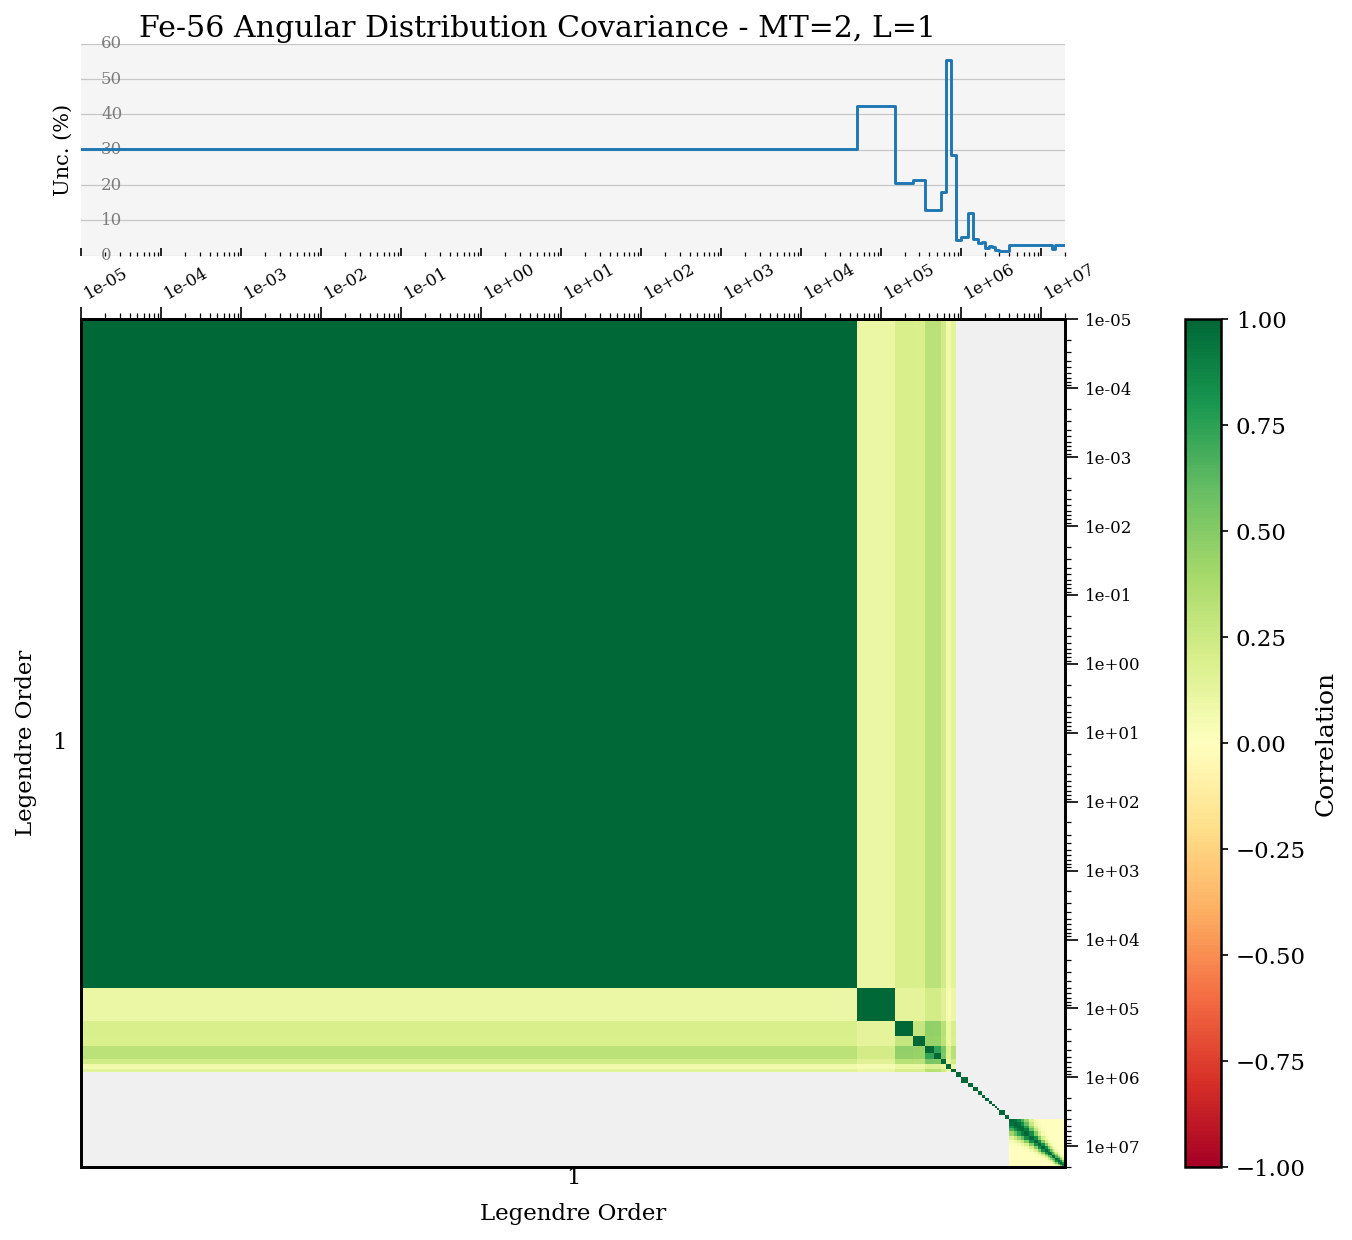

In [5]:
# Create heatmap with custom title
fig = (HeatmapBuilder()
       .add_heatmap(heatmap_data)
       .set_labels(title=f"Fe-56 Angular Distribution Covariance - MT={mt_to_plot}, L={l_to_plot}")
       .build())
plt.show()

## Example 3: Hide Title

Remove the title completely by setting it to an empty string or None.

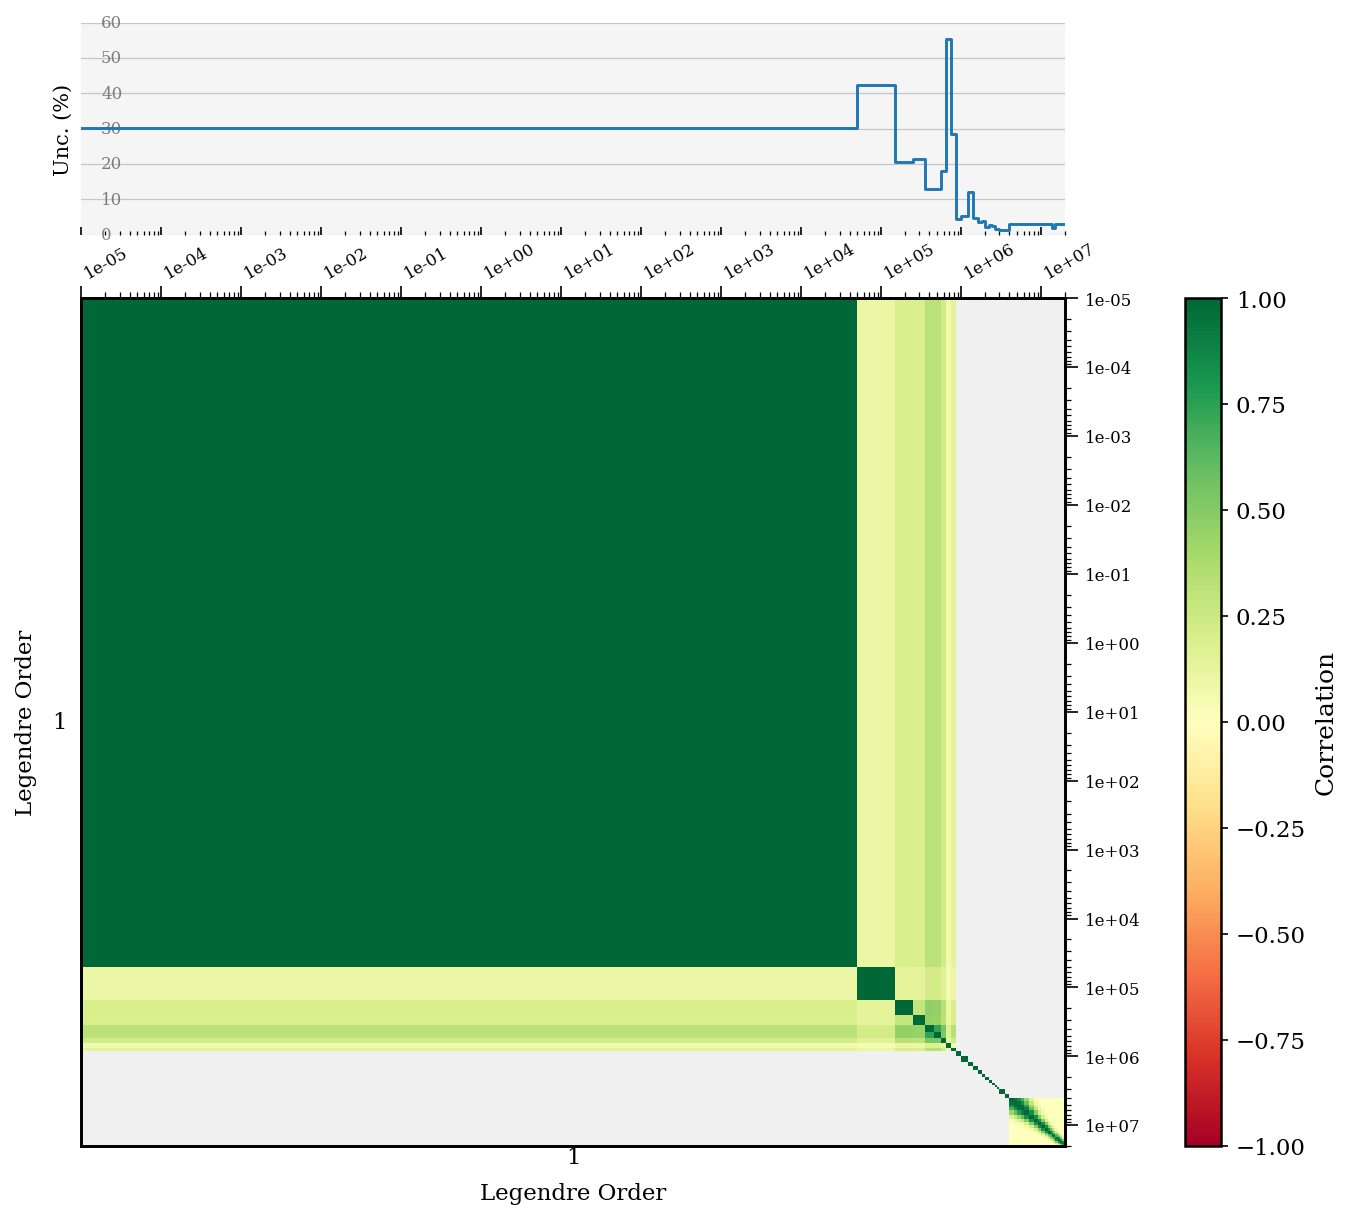

In [6]:
# Create heatmap without title
fig = (HeatmapBuilder()
       .add_heatmap(heatmap_data)
       .set_labels(title="")
       .build())
plt.show()

## Example 4: Customize Font Sizes

Adjust font sizes for energy ticks, block labels, and colorbar.

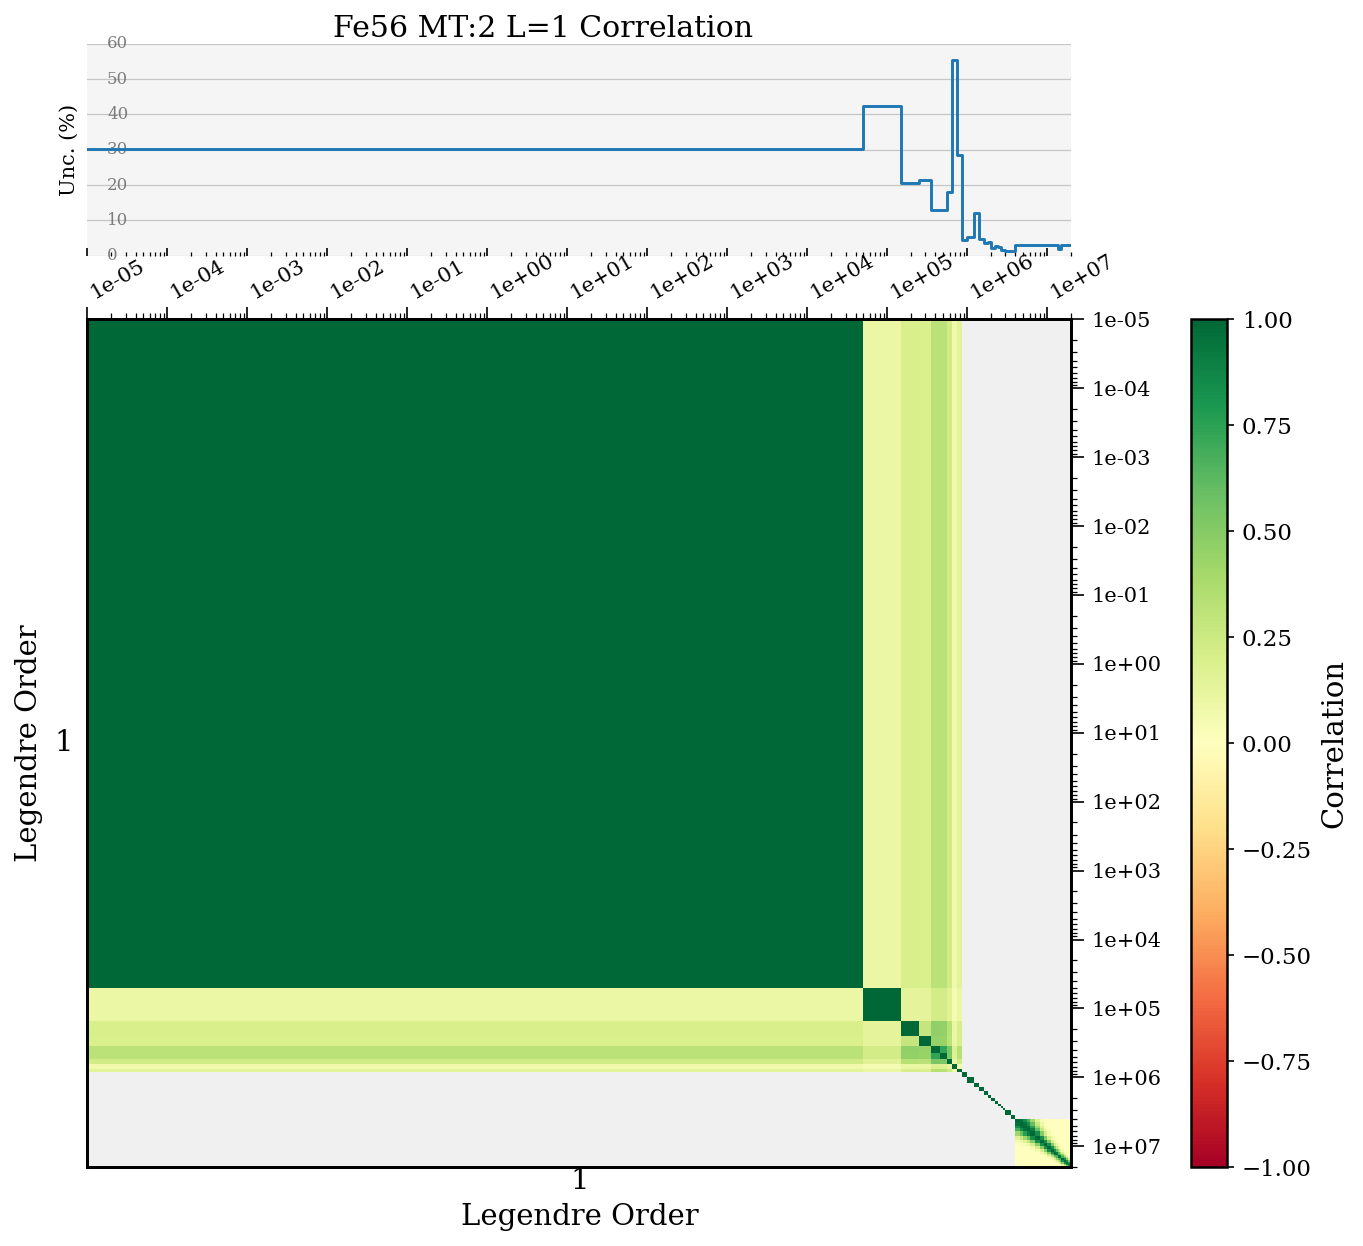

In [7]:
# Create heatmap with custom font sizes
fig = (HeatmapBuilder()
       .add_heatmap(heatmap_data,
                    energy_tick_fontsize=10,
                    block_label_fontsize=14,
                    colorbar_fontsize=14)
       .build())
plt.show()

## Example 5: Hide Optional Elements

Disable energy ticks, block labels, uncertainties panel, and/or colorbar.

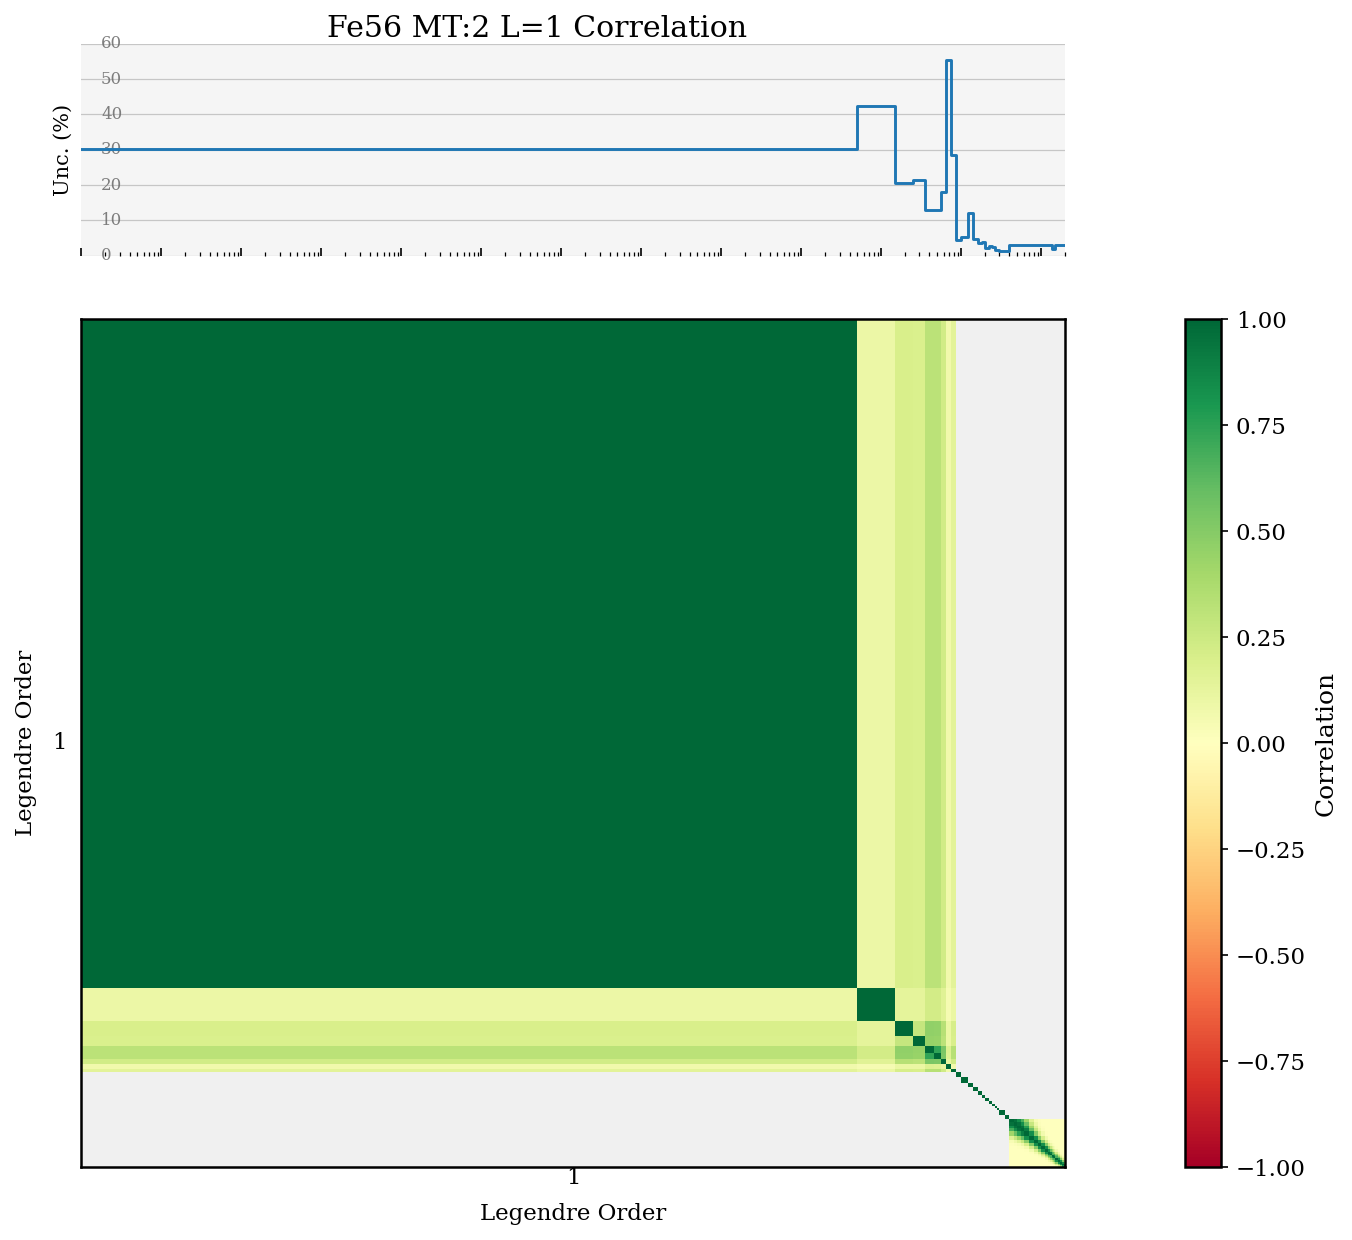

In [8]:
# Create heatmap without energy ticks
fig = (HeatmapBuilder()
       .add_heatmap(heatmap_data,
                    show_energy_ticks=False)
       .build())
plt.show()

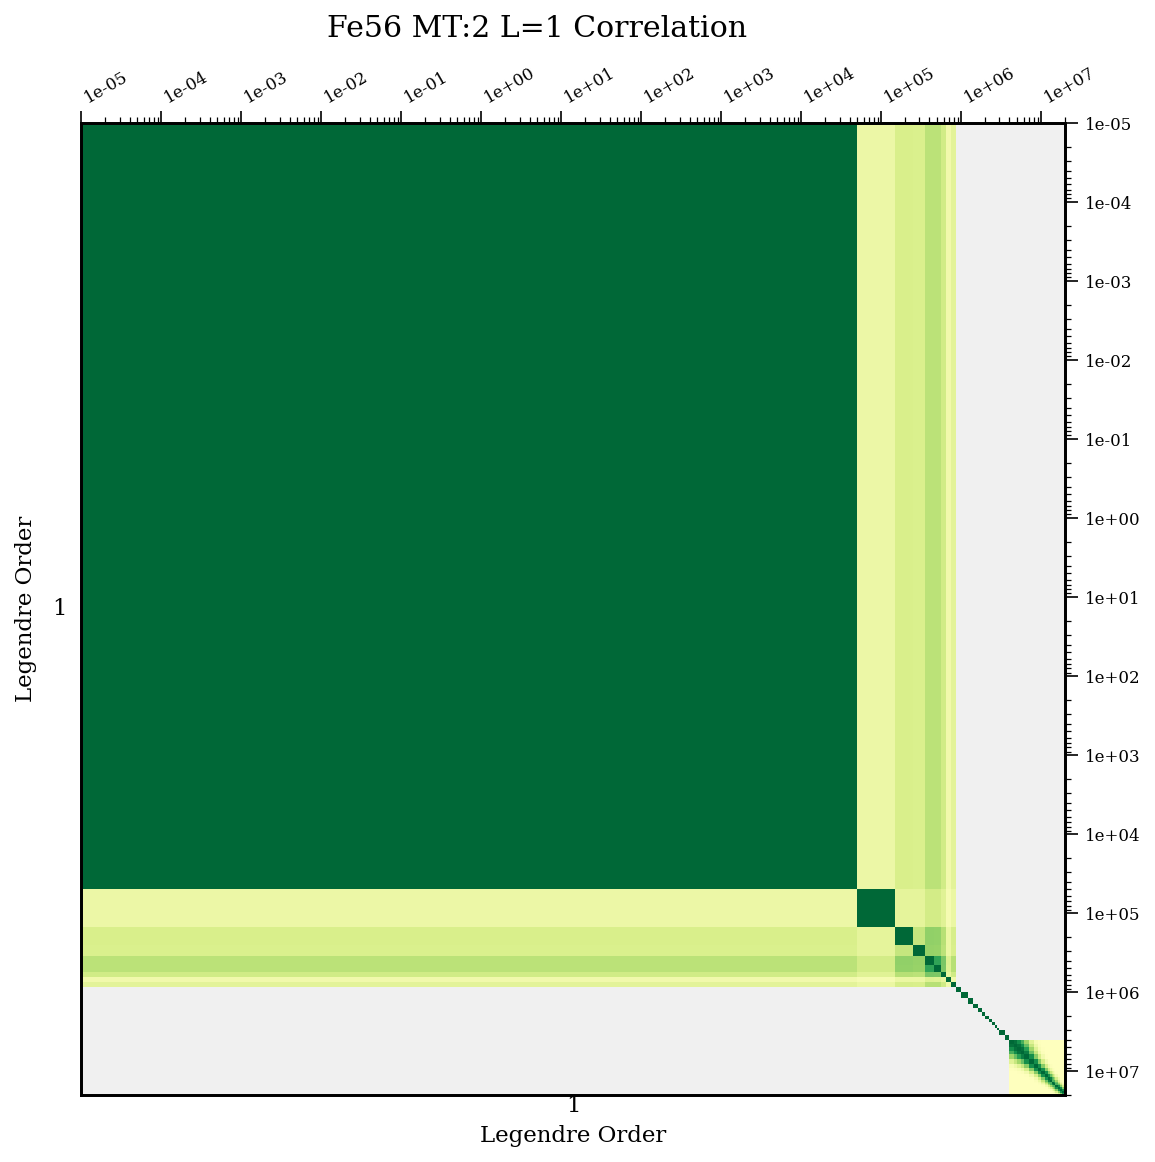

In [9]:
# Create minimal heatmap without uncertainties and colorbar
fig = (HeatmapBuilder()
       .add_heatmap(heatmap_data,
                    show_uncertainties=False,
                    show_colorbar=False)
       .build())
plt.show()

## Example 6: Custom Colormap

Override the default colormap with a custom one.

## Example 6a: Covariance Matrix (instead of Correlation)

Show the covariance matrix instead of the correlation matrix.

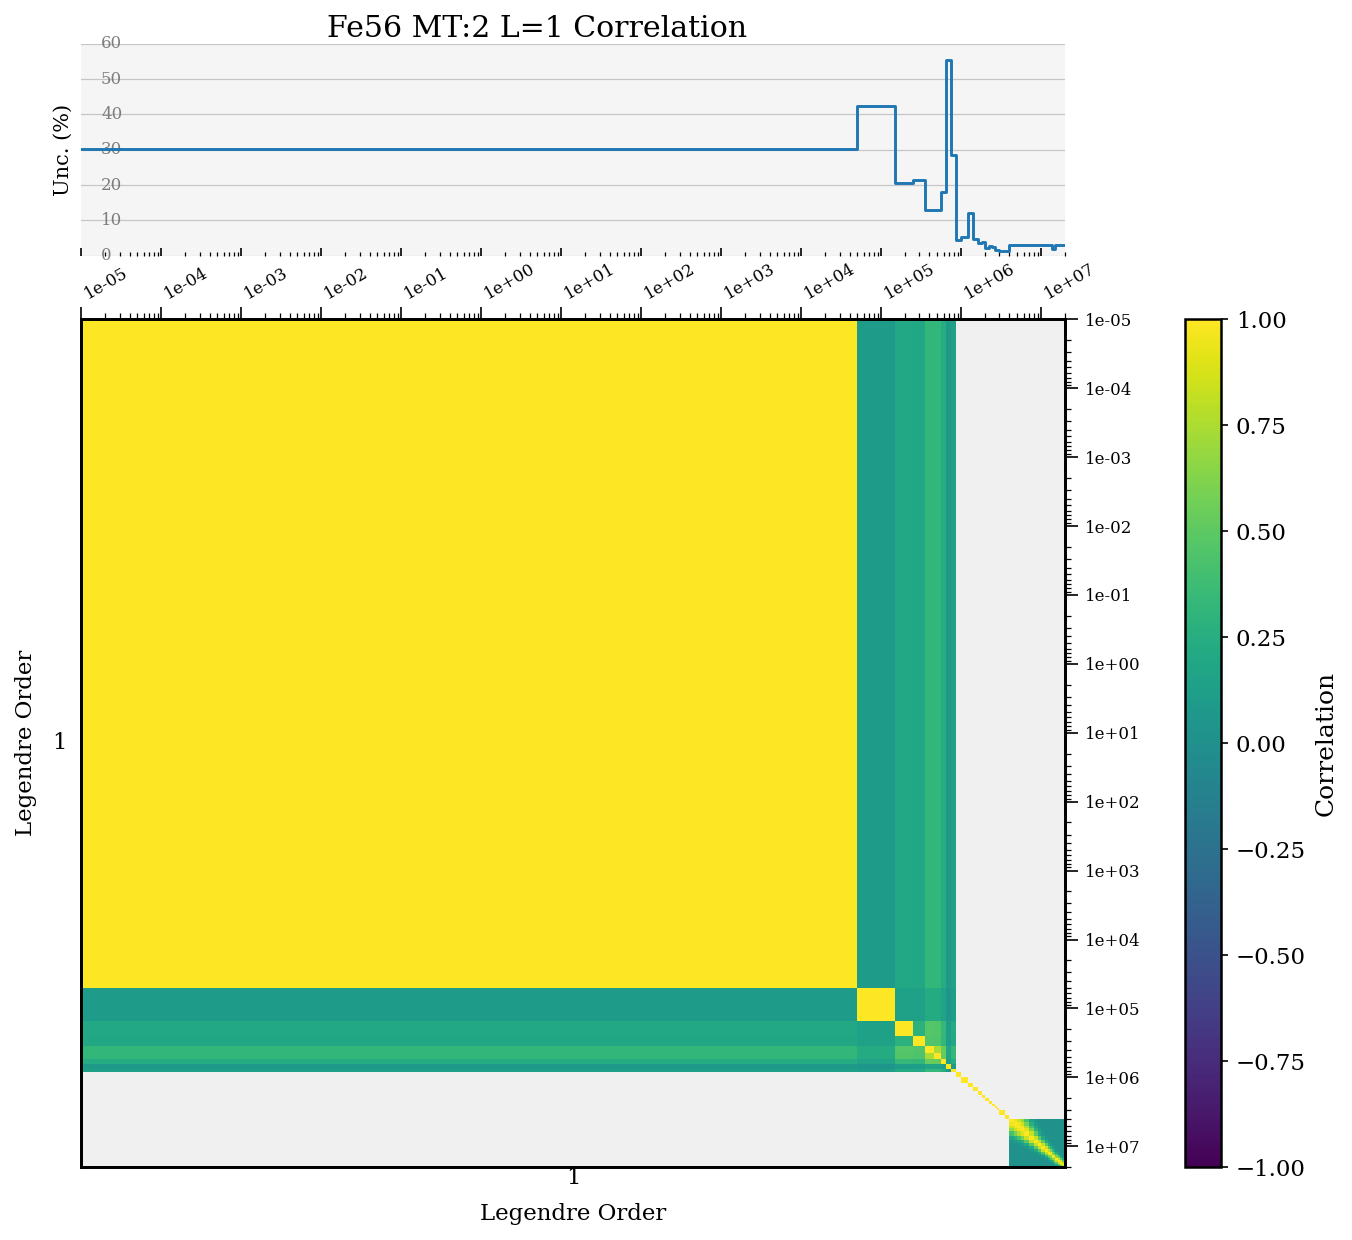

In [10]:
# Create heatmap with custom colormap
fig = (HeatmapBuilder()
       .add_heatmap(heatmap_data,
                    cmap='viridis')  # Use viridis colormap
       .build())
plt.show()

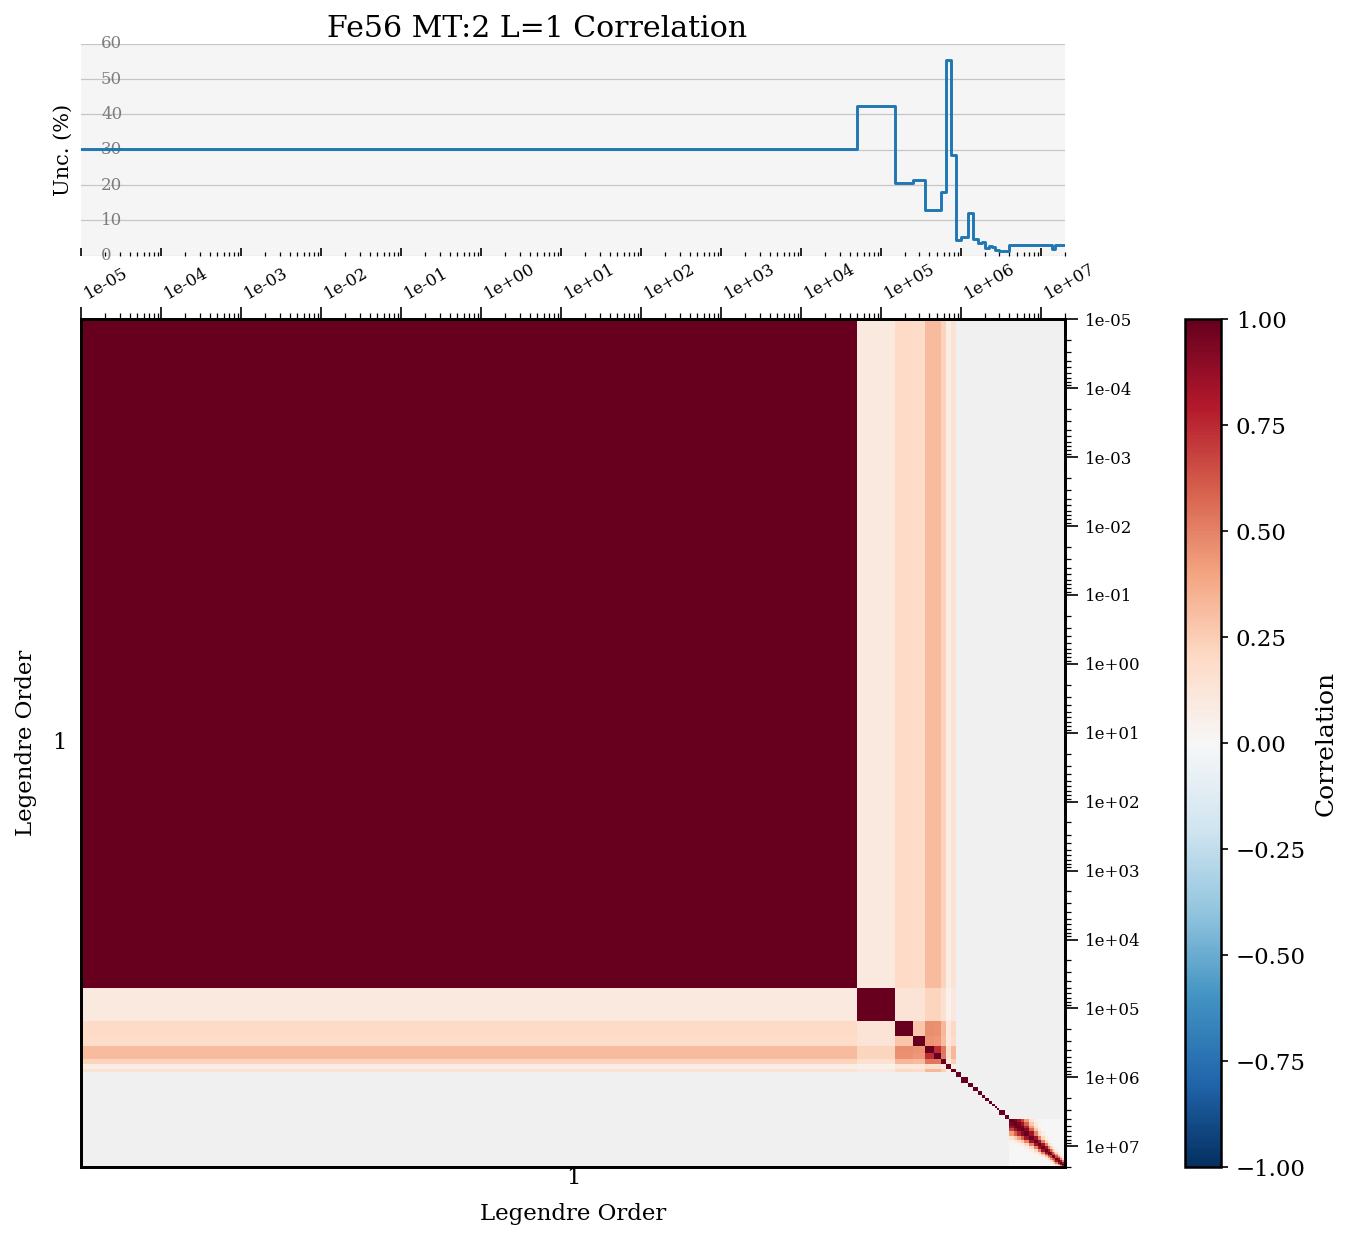

In [11]:
# Create correlation heatmap with diverging colormap
fig = (HeatmapBuilder()
       .add_heatmap(heatmap_data,
                    cmap='RdBu_r')  # Red-Blue reversed colormap
       .build())
plt.show()

## Example 7: Multiple MT Reactions (Multi-Block Heatmap)

Plot covariance data for multiple MT reactions in a single heatmap with block labels.

## Example 6c: Off-Diagonal Block (Cross-Legendre Correlation)

Plot the correlation between two different Legendre coefficients.

Creating multi-block heatmap for MT=2, L=[np.int64(1), np.int64(2), np.int64(3)]


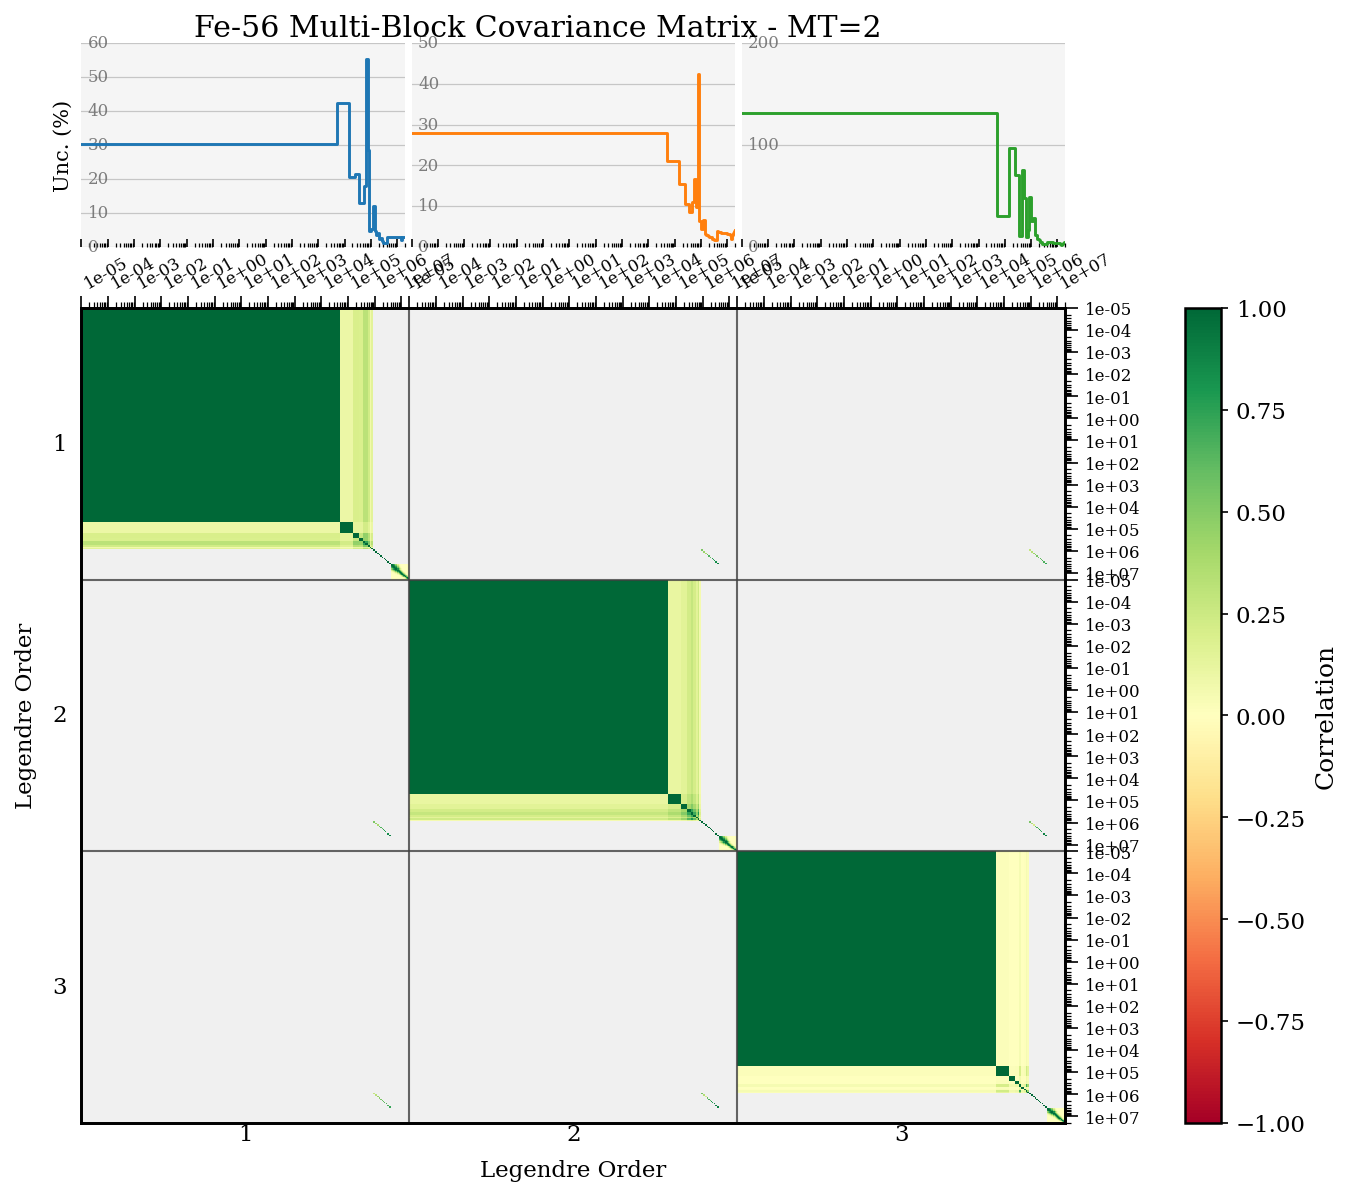

In [37]:
# Create multi-block heatmap with multiple Legendre coefficients
# Get available Legendre coefficients for the selected MT
summary_filtered = summary[summary['MT_row'] == mt_to_plot]
available_l = sorted(summary_filtered['L_row'].unique())

if len(available_l) >= 2:
    # Select up to 3 Legendre coefficients
    ls_to_plot = available_l[:min(3, len(available_l))]
    
    print(f"Creating multi-block heatmap for MT={mt_to_plot}, L={ls_to_plot}")
    
    # Convert covariance data to heatmap format for multiple Legendre coefficients
    heatmap_data_multi = mf34_covmat.to_heatmap_data(
        nuclide=isotope,
        mt=mt_to_plot,
        legendre_coeffs=ls_to_plot,
        matrix_type='corr',
        scale='log'
    )
    
    # Create multi-block heatmap
    fig = (HeatmapBuilder()
           .add_heatmap(heatmap_data_multi)
           .set_labels(title=f"Fe-56 Multi-Block Covariance Matrix - MT={mt_to_plot}")
           .build())
    plt.show()
else:
    print(f"Only {len(available_l)} Legendre coefficient(s) available for MT={mt_to_plot}")

## Example 8: Custom Figure Size and DPI

Control the figure size and resolution.

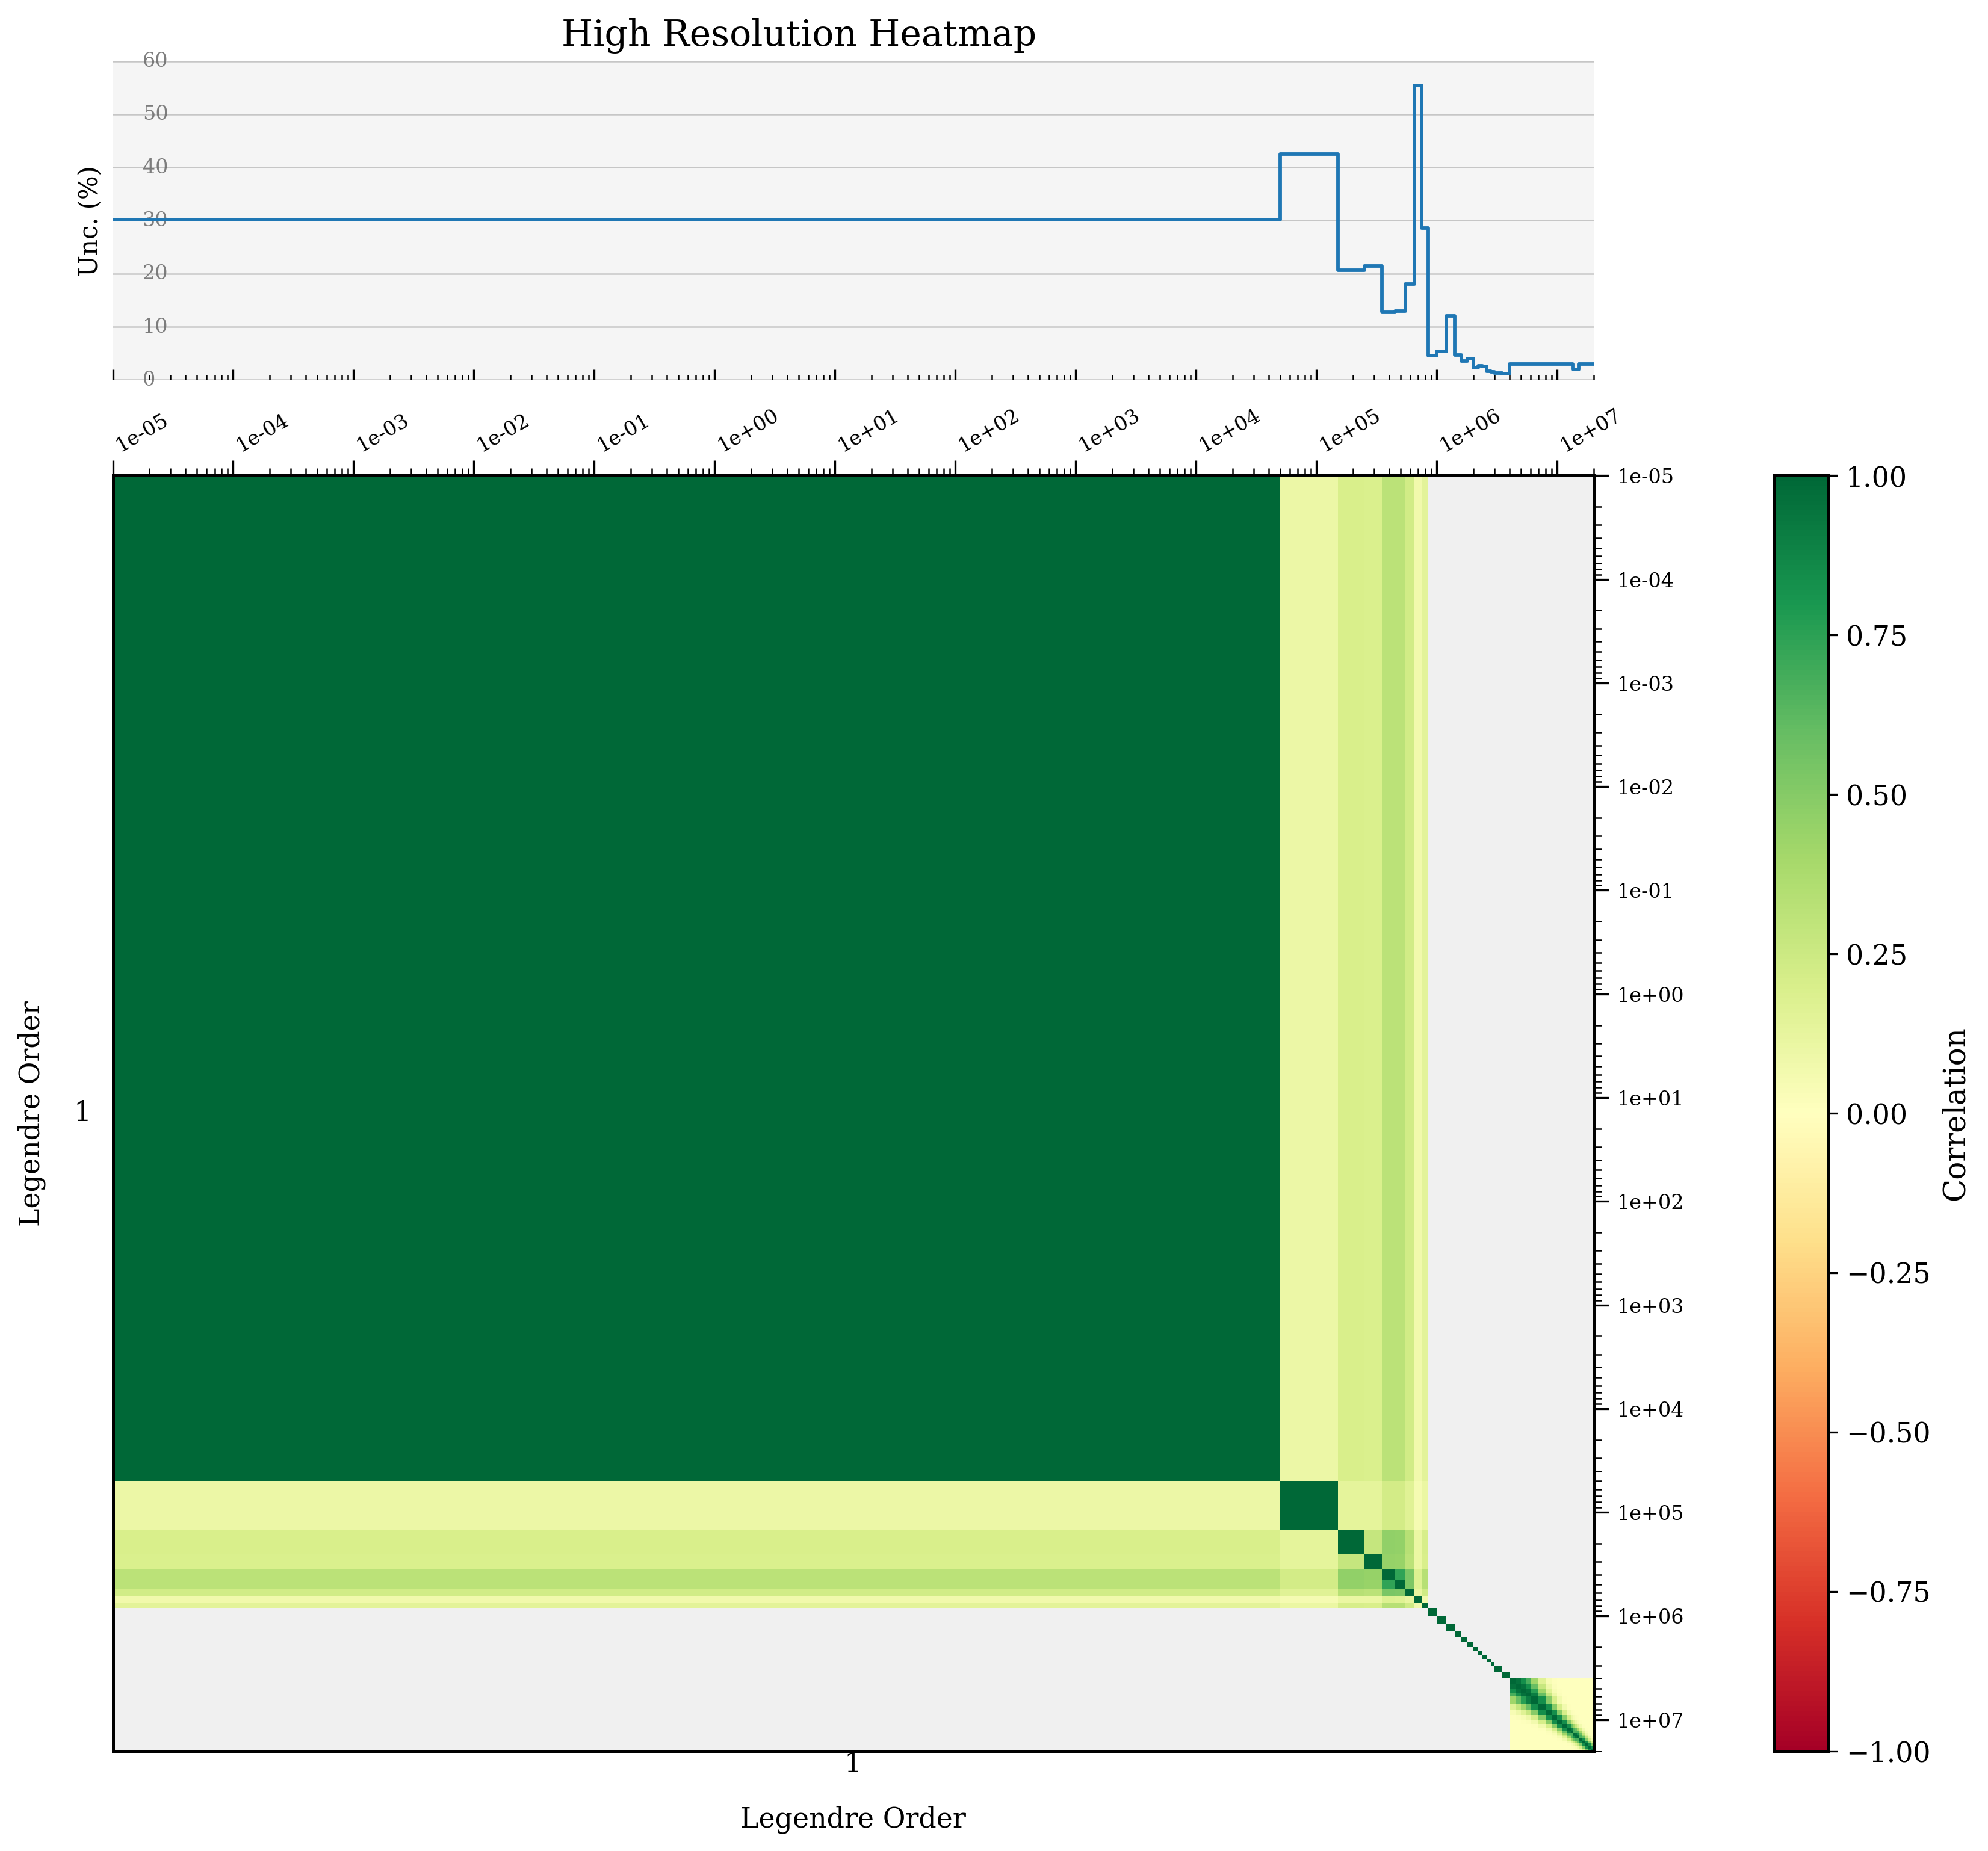

In [13]:
# Create heatmap with custom figure size and DPI
fig = (HeatmapBuilder(figsize=(10, 10), dpi=300)
       .add_heatmap(heatmap_data)
       .set_labels(title="High Resolution Heatmap")
       .build())
plt.show()

## Example 9: Dark Style Theme

Use the dark style for presentations or dark backgrounds.

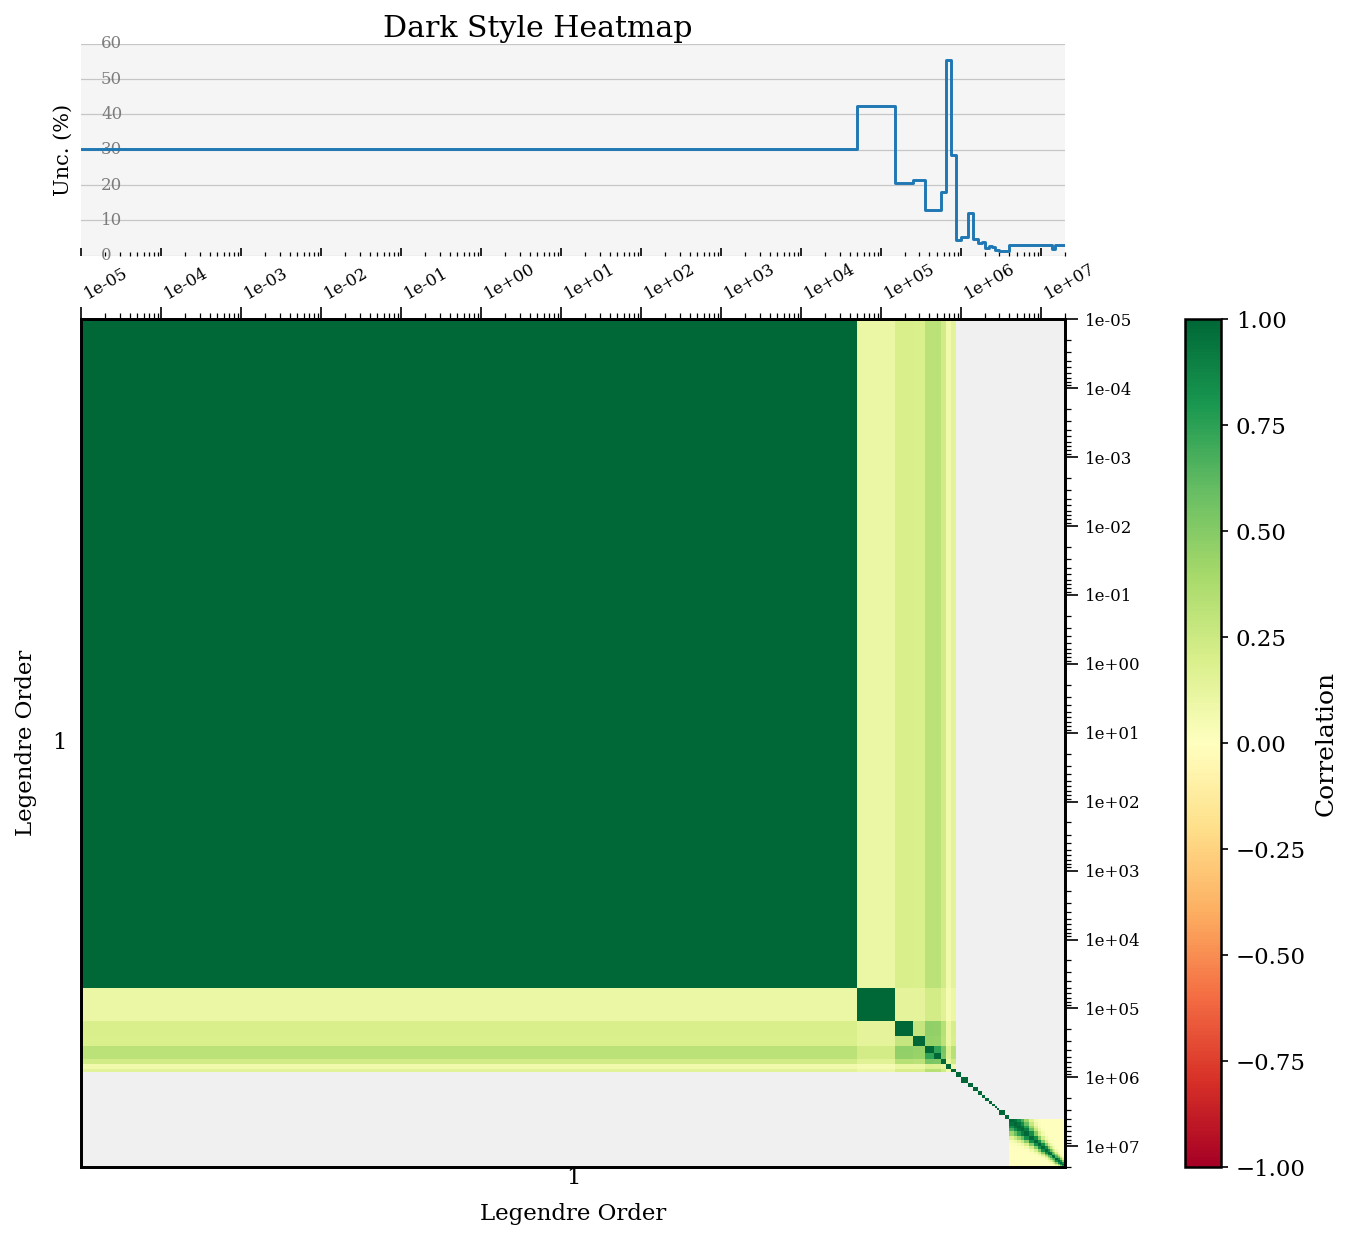

In [14]:
# Create heatmap with dark style
fig = (HeatmapBuilder(style='dark')
       .add_heatmap(heatmap_data)
       .set_labels(title="Dark Style Heatmap")
       .build())
plt.show()

## Example 10: Complete Customization

Combine multiple customization options for a publication-ready plot.

## Example 11: Energy Range Filtering (Single Block)

Use `set_limits()` to zoom into a specific energy range for single-block heatmaps.

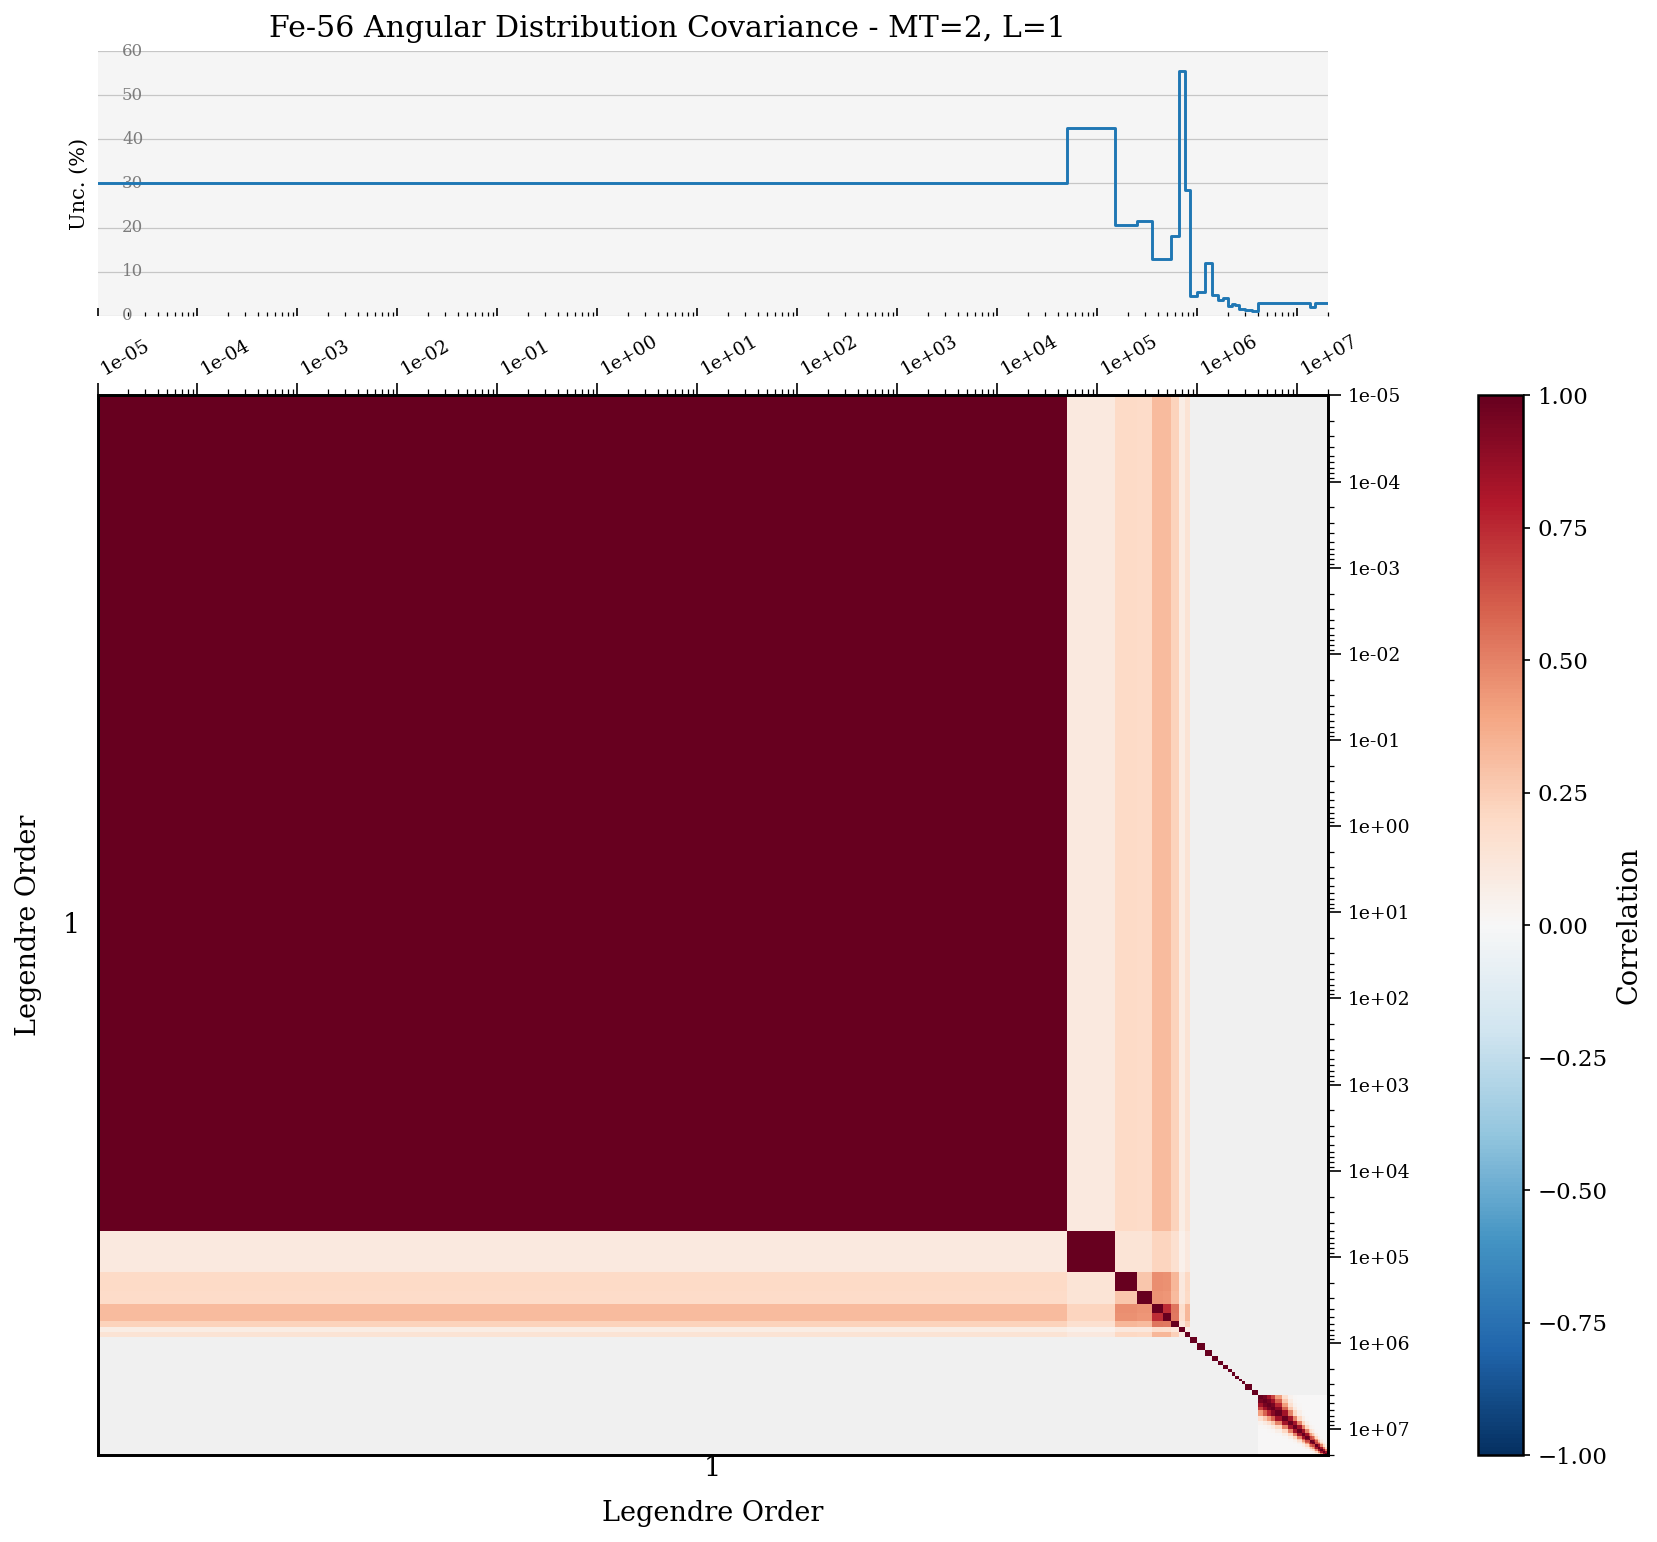

In [20]:
# Create fully customized publication-ready heatmap
fig = (HeatmapBuilder(
           style='light',
           figsize=(10, 10),
           dpi=150,
           font_family='serif'
       )
       .add_heatmap(
           heatmap_data,
           show_uncertainties=True,
           show_energy_ticks=True,
           show_block_labels=True,
           show_colorbar=True,
           energy_tick_fontsize=9,
           block_label_fontsize=13,
           colorbar_fontsize=13,
           cmap='RdBu_r'
       )
       .set_labels(
           title=f"Fe-56 Angular Distribution Covariance - MT={mt_to_plot}, L={l_to_plot}",
           x_label="Energy Group Index",
           y_label="Energy Group Index"
       )
       .build())
plt.show()

## Summary

This notebook demonstrated the following `HeatmapBuilder` use cases with MF34 covariance data:

1. **Basic heatmap** - Default settings with automatic title
2. **Custom title** - Override the default title
3. **Hide title** - Remove the title completely
4. **Font size customization** - Adjust tick and label sizes
5. **Hide optional elements** - Control visibility of ticks, labels, uncertainties, and colorbar
6. **Custom colormap** - Override the default color scheme
   - **6a. Covariance vs Correlation** - Show absolute covariance values instead of correlation
   - **6b. String isotope identifier** - Use 'Fe56' instead of ZAID numbers
   - **6c. Off-diagonal blocks** - Cross-Legendre coefficient correlations
7. **Multi-block heatmap** - Plot multiple Legendre coefficients with block labels
8. **Figure size and DPI** - Control output dimensions and resolution
9. **Dark style** - Alternative color scheme for presentations
10. **Complete customization** - Combine all options for publication-ready plots
11. **Energy range filtering (single block)** - Use `set_limits()` to zoom into specific energy ranges
12. **Energy range filtering (multi-block)** - Apply energy filtering across multiple blocks

All examples use MF34 angular distribution covariance data from the Fe-56 ENDF file.

### Key KIKA API Methods Used:

- `read_endf(filepath, mf_numbers=34)` - Load ENDF file with MF34 data
- `endf.files[34].to_ang_covmat()` - Convert MF34 to MF34CovMat object
- `mf34_covmat.to_heatmap_data()` - Prepare data for plotting
  - `nuclide`: ZAID (e.g., 26056) or string (e.g., 'Fe56')
  - `mt`: Reaction type (MT number)
  - `legendre_coeffs`: Single L, list of L values, or (L1, L2) tuple for off-diagonal
  - `matrix_type`: 'corr' for correlation, 'cov' for covariance
  - `scale`: 'log' or 'linear' for energy axis
- `HeatmapBuilder().add_heatmap(data).build()` - Create the plot
- `set_limits(x_lim=(emin, emax), y_lim=(emin, emax))` - Filter to specific energy ranges
  - Energy values in eV (e.g., 1e3 for 1 keV, 1e6 for 1 MeV)
  - Both limits must be specified as tuples with two values
  - Can use asymmetric limits to show cross-correlations between energy regions

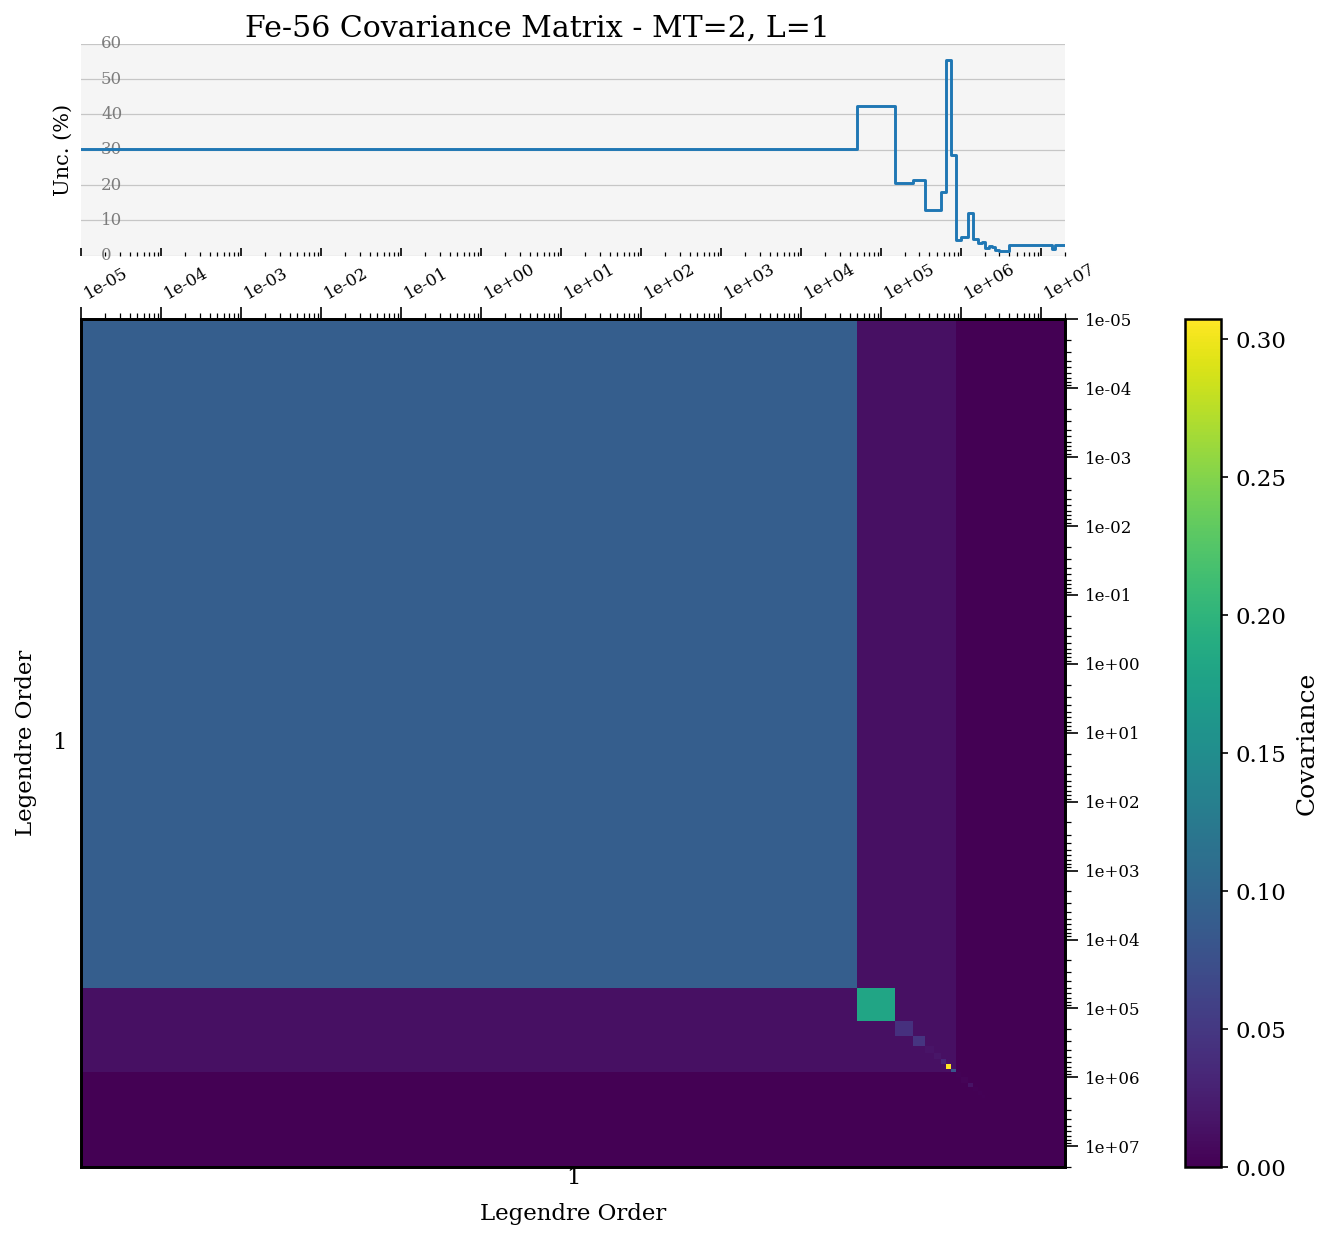

In [21]:
# Create heatmap showing covariance matrix (absolute values)
heatmap_data_cov = mf34_covmat.to_heatmap_data(
    nuclide=isotope,
    mt=mt_to_plot,
    legendre_coeffs=l_to_plot,
    matrix_type='cov',  # Use covariance matrix
    scale='log'
)

fig = (HeatmapBuilder()
       .add_heatmap(heatmap_data_cov)
       .set_labels(title=f"Fe-56 Covariance Matrix - MT={mt_to_plot}, L={l_to_plot}")
       .build())
plt.show()

## Example 6b: Using String Isotope Identifier

You can use string symbols like 'Fe56' instead of ZAID numbers.

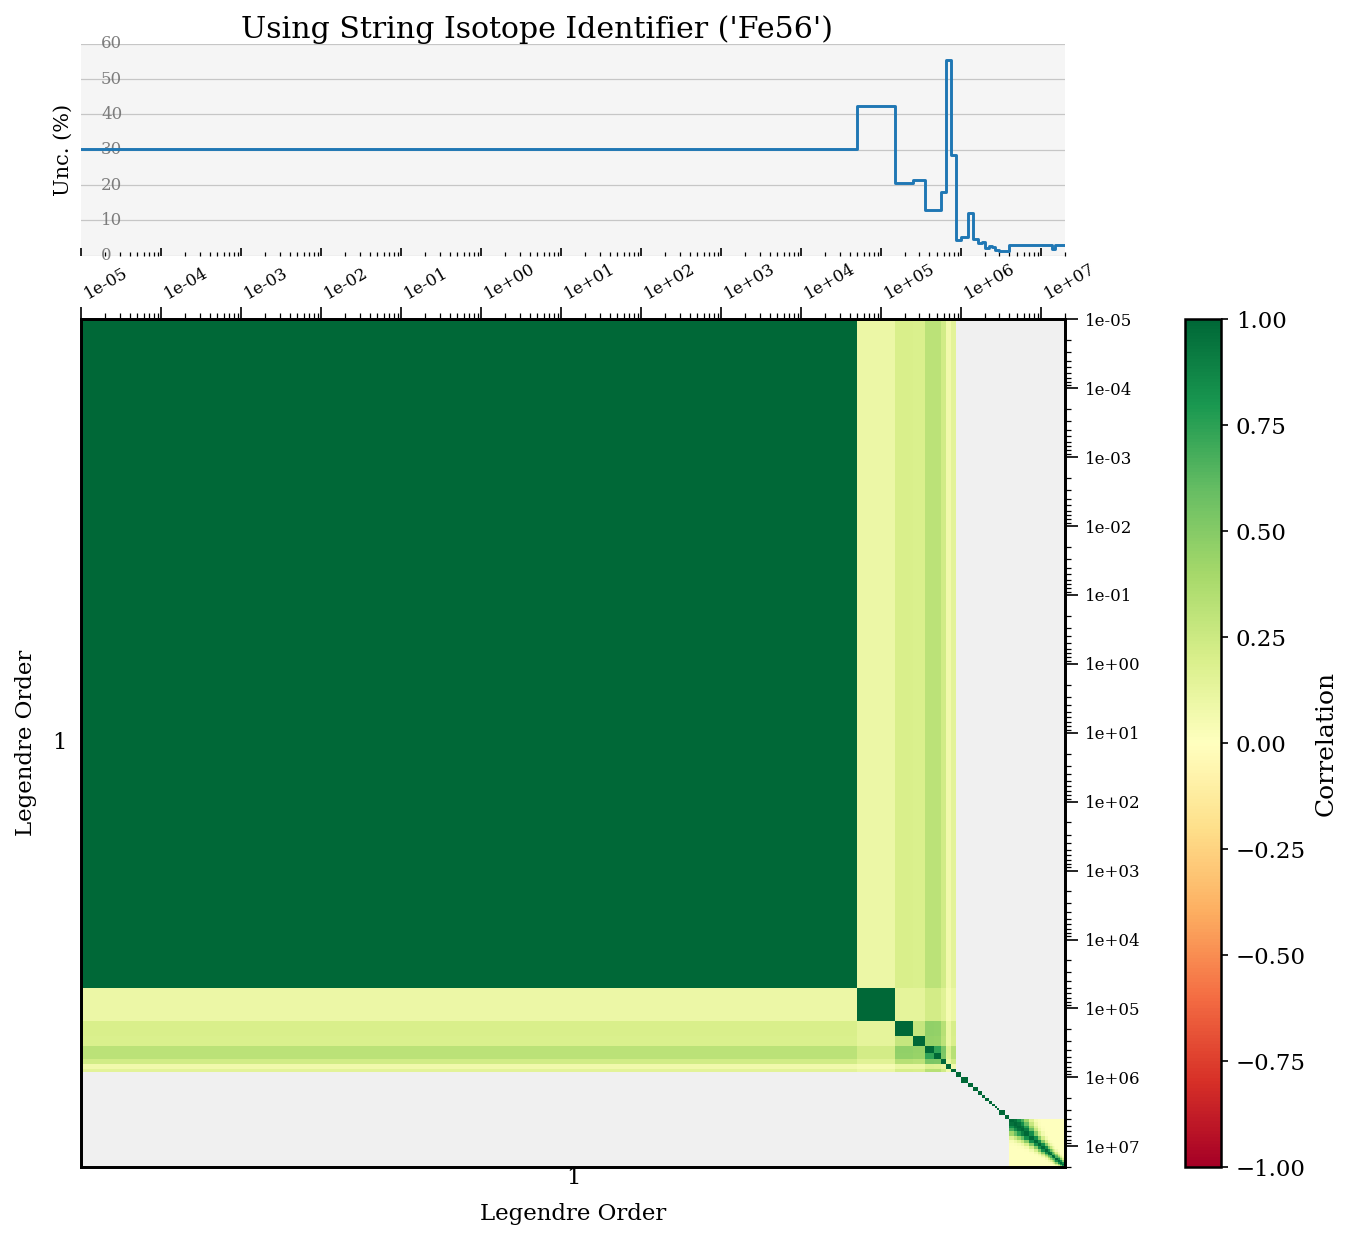

In [22]:
# Create heatmap using string isotope identifier
heatmap_data_str = mf34_covmat.to_heatmap_data(
    nuclide='Fe56',  # String identifier instead of ZAID
    mt=mt_to_plot,
    legendre_coeffs=l_to_plot,
    matrix_type='corr',
    scale='log'
)

fig = (HeatmapBuilder()
       .add_heatmap(heatmap_data_str)
       .set_labels(title="Using String Isotope Identifier ('Fe56')")
       .build())
plt.show()

Creating off-diagonal block for L=1 vs L=2


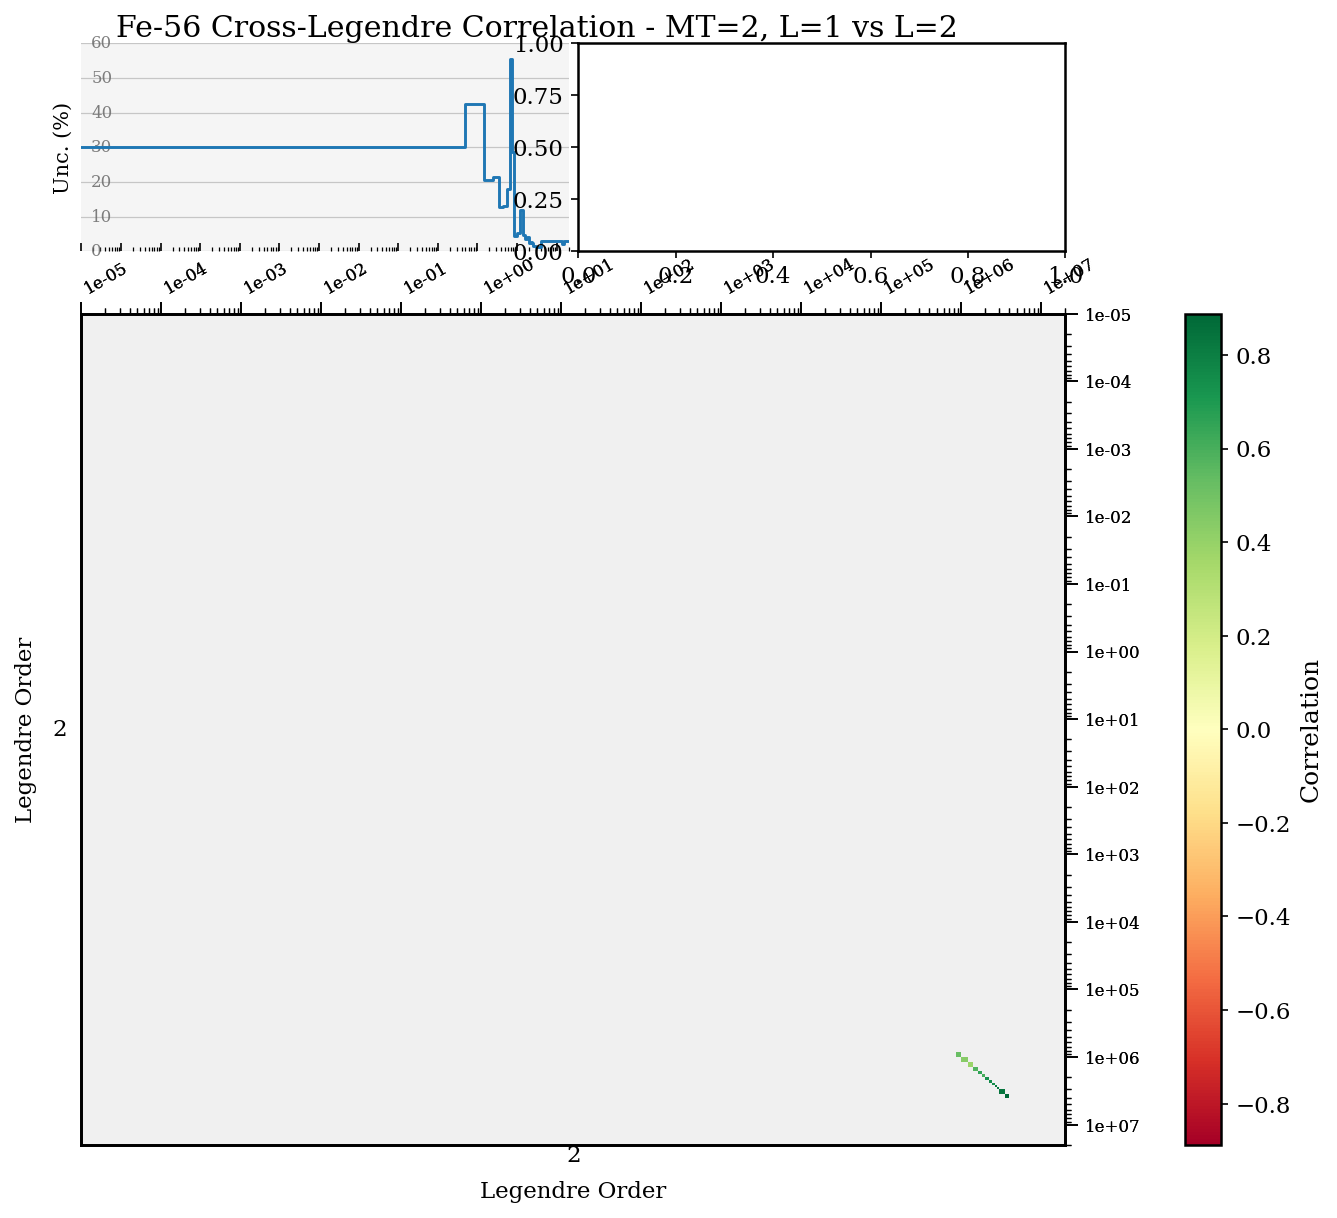

In [23]:
# Create off-diagonal block heatmap (correlation between two Legendre coefficients)
if len(available_l) >= 2:
    l1 = available_l[0]
    l2 = available_l[1]
    
    print(f"Creating off-diagonal block for L={l1} vs L={l2}")
    
    # Use tuple to specify off-diagonal block
    heatmap_data_offdiag = mf34_covmat.to_heatmap_data(
        nuclide=isotope,
        mt=mt_to_plot,
        legendre_coeffs=(l1, l2),  # Tuple for off-diagonal block
        matrix_type='corr',
        scale='log'
    )
    
    fig = (HeatmapBuilder()
           .add_heatmap(heatmap_data_offdiag)
           .set_labels(title=f"Fe-56 Cross-Legendre Correlation - MT={mt_to_plot}, L={l1} vs L={l2}")
           .build())
    plt.show()
else:
    print("Need at least 2 Legendre coefficients for off-diagonal block")

In [24]:
# Alternative way: Load MF34 data directly
mf34_covmat_alt = MF34CovMat.from_endf(endf_file, energy_unit='eV')

print("Alternative loading method:")
print(f"Number of matrices: {mf34_covmat_alt.num_matrices}")
print("\nThis is equivalent to:")
print("1. endf = read_endf(filepath, mf_numbers=34)")
print("2. mf34_covmat = endf.files[34].to_ang_covmat()")

Alternative loading method:
Number of matrices: 21

This is equivalent to:
1. endf = read_endf(filepath, mf_numbers=34)
2. mf34_covmat = endf.files[34].to_ang_covmat()


Energy grid range: 1.00e-05 eV to 2.00e+07 eV
                   0.00 keV to 20.00 MeV


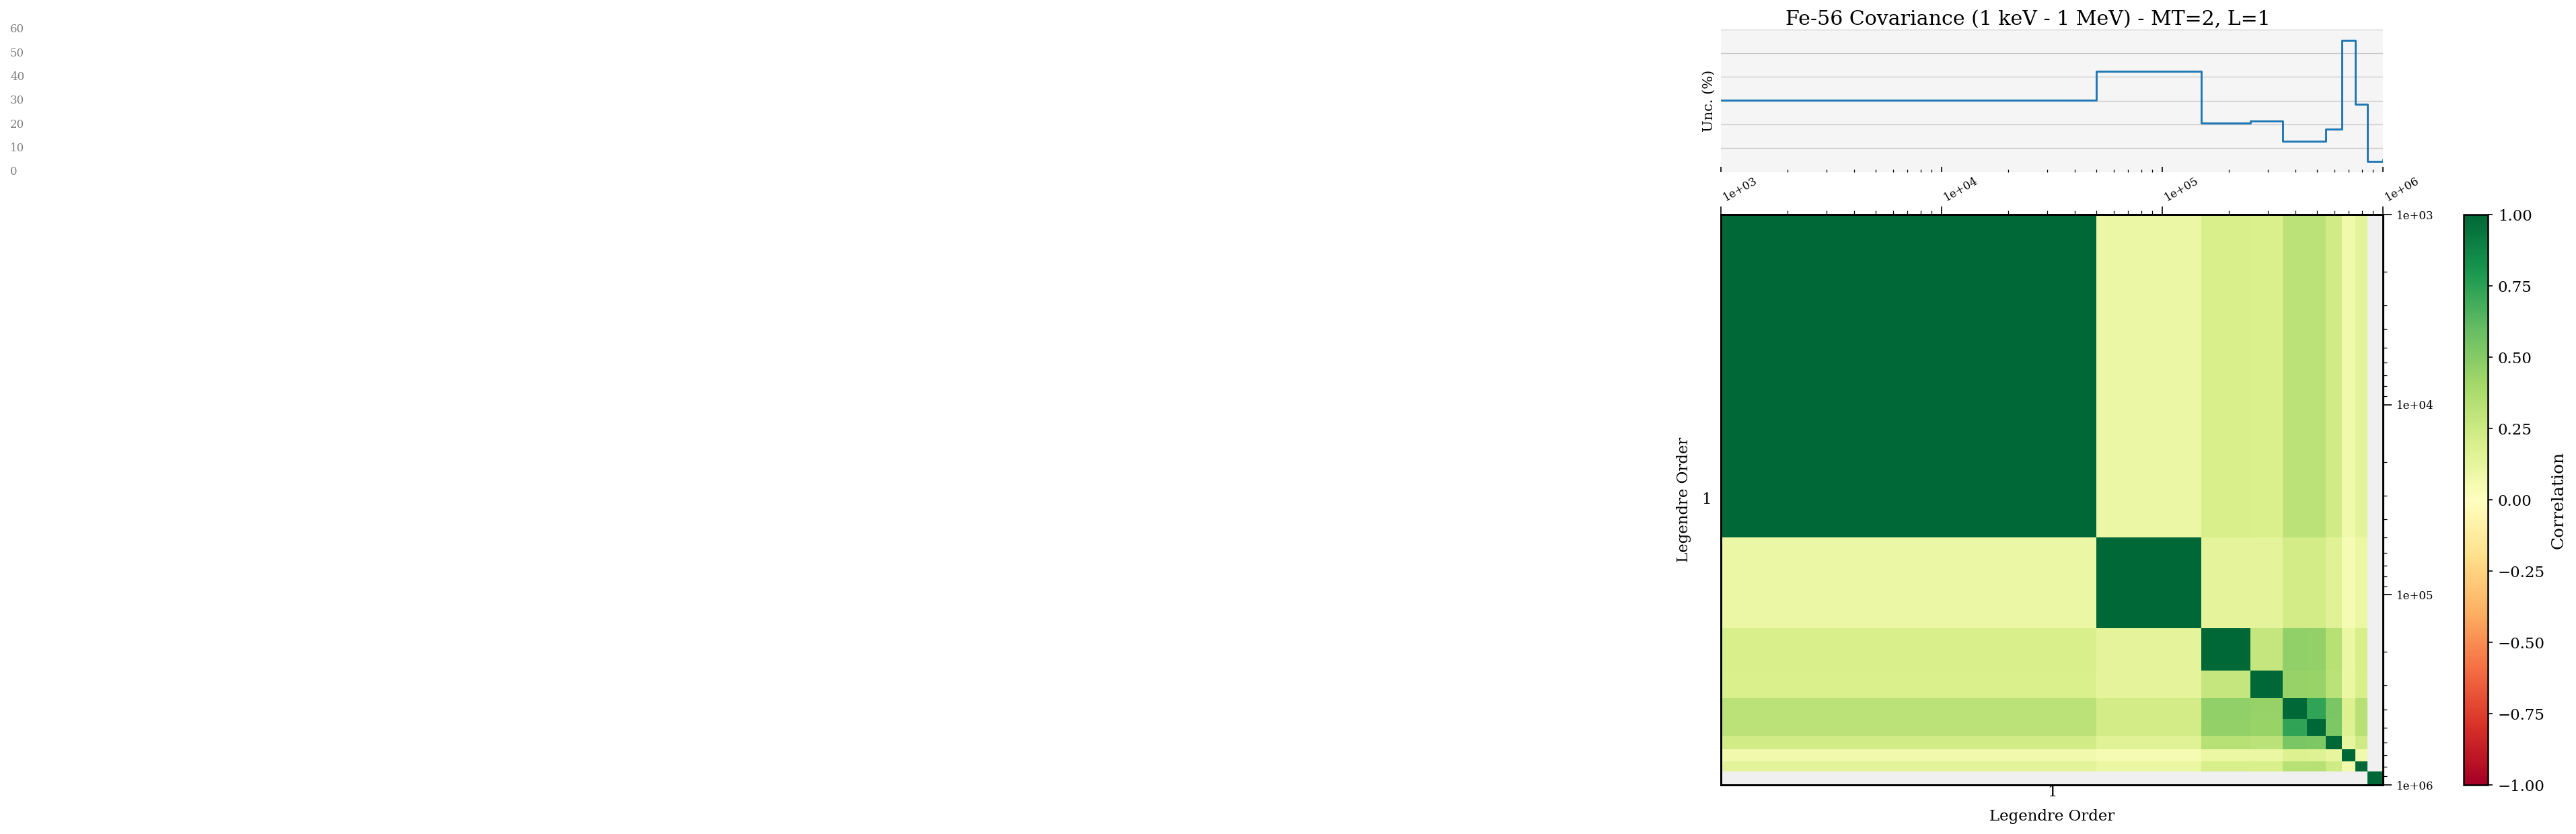


Note: Energy limits are specified in eV
Example: 1 keV = 1e3 eV, 1 MeV = 1e6 eV


In [35]:
# Create heatmap with energy range filtering (single block)
# First, check the energy range in the data
if hasattr(heatmap_data, 'energy_grids') and heatmap_data.energy_grids is not None:
    # Get the energy grid for the first Legendre coefficient
    first_l = list(heatmap_data.energy_grids.keys())[0]
    eg = heatmap_data.energy_grids[first_l]
    print(f"Energy grid range: {eg.min():.2e} eV to {eg.max():.2e} eV")
    print(f"                   {eg.min()/1e3:.2f} keV to {eg.max()/1e6:.2f} MeV")
    
    # Filter to show only energies between 1 keV and 1 MeV
    fig = (HeatmapBuilder()
           .add_heatmap(heatmap_data)
           .set_limits(x_lim=(1e3, 1e6), y_lim=(1e3, 1e6))  # 1 keV to 1 MeV
           .set_labels(
               title=f"Fe-56 Covariance (1 keV - 1 MeV) - MT={mt_to_plot}, L={l_to_plot}"
           )
           .build())
    plt.show()
    
    print("\nNote: Energy limits are specified in eV")
    print("Example: 1 keV = 1e3 eV, 1 MeV = 1e6 eV")
else:
    print("Energy grid not available in heatmap data")

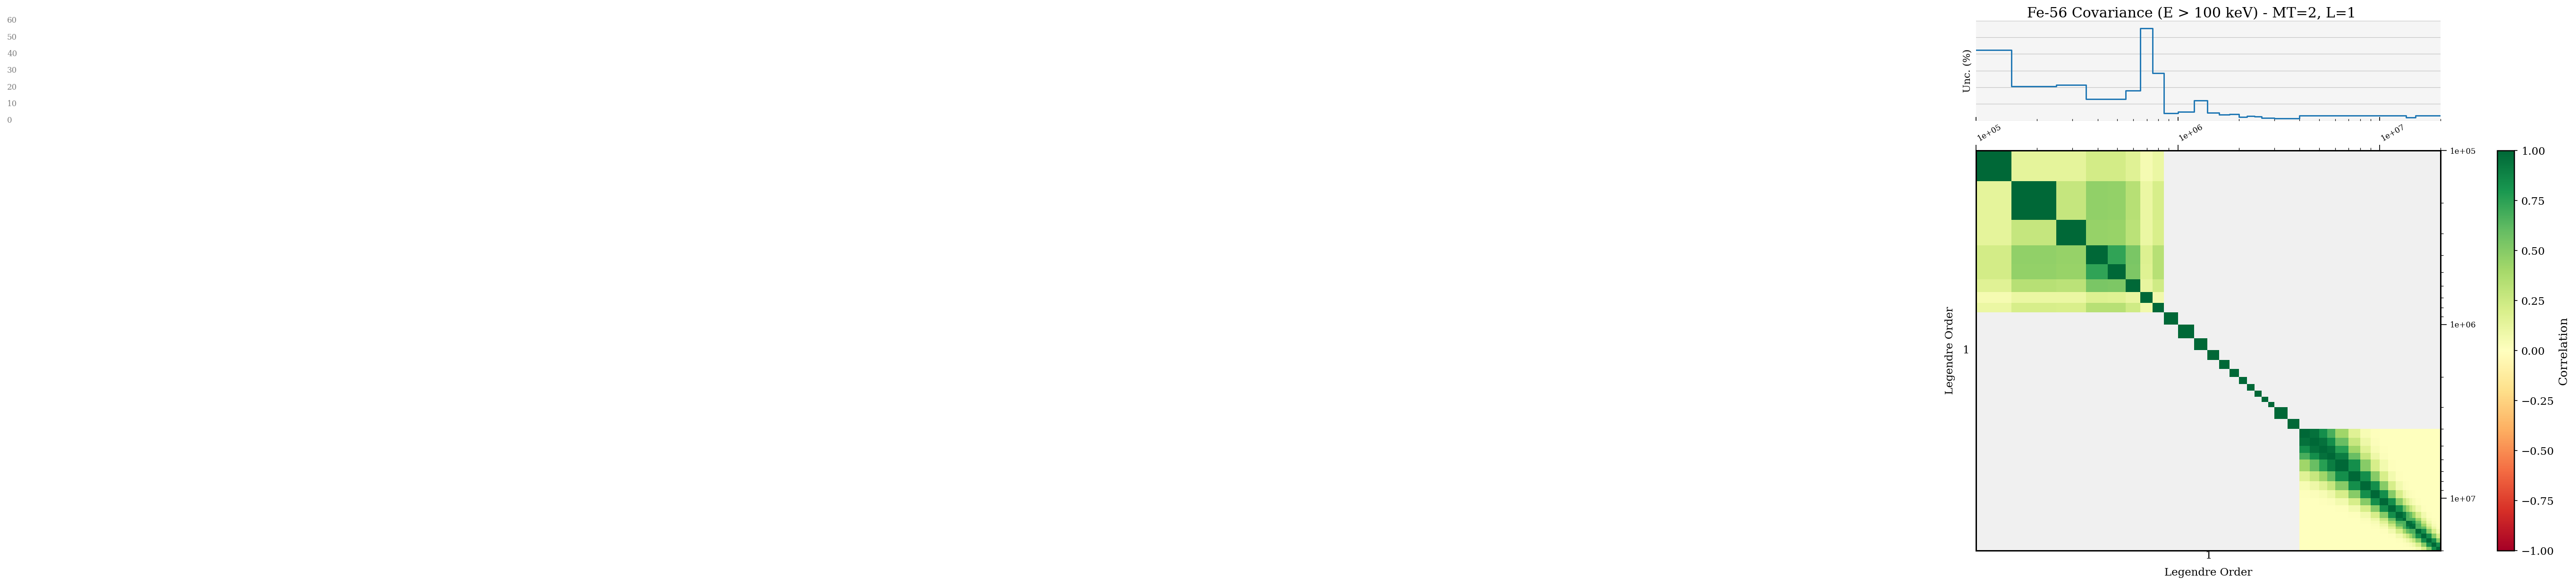


Zoomed to high energy region: 100 keV to 20.00 MeV


In [36]:
# Another example: zoom to high energy region (above 100 keV)
if hasattr(heatmap_data, 'energy_grids') and heatmap_data.energy_grids is not None:
    first_l = list(heatmap_data.energy_grids.keys())[0]
    eg = heatmap_data.energy_grids[first_l]
    e_max = eg.max()
    
    fig = (HeatmapBuilder()
           .add_heatmap(heatmap_data)
           .set_limits(x_lim=(1e5, e_max), y_lim=(1e5, e_max))  # Above 100 keV
           .set_labels(
               title=f"Fe-56 Covariance (E > 100 keV) - MT={mt_to_plot}, L={l_to_plot}"
           )
           .build())
    plt.show()
    
    print(f"\nZoomed to high energy region: 100 keV to {e_max/1e6:.2f} MeV")

## Example 12: Energy Range Filtering (Multi-Block)

Apply energy filtering to multi-block heatmaps. The energy limits apply across all blocks.

Creating filtered multi-block heatmap for L=[np.int64(1), np.int64(2), np.int64(3)]


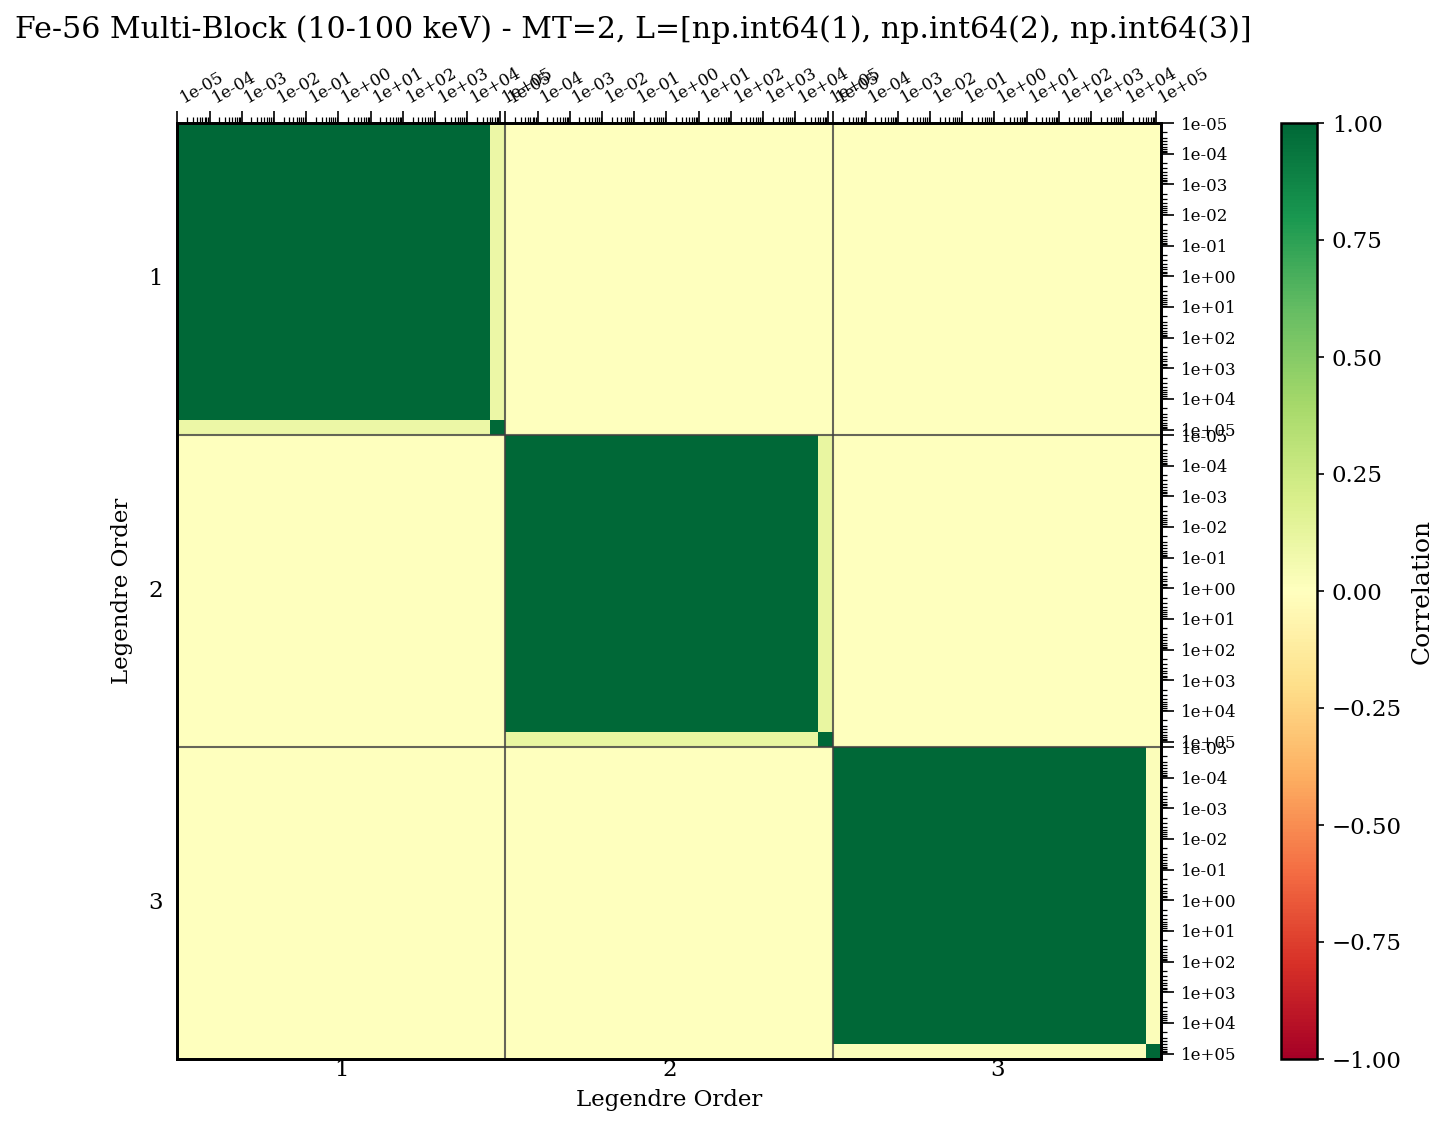


For multi-block heatmaps, energy limits filter data across all blocks
Each block shows only energy groups within the specified range


In [39]:
# Create multi-block heatmap with energy filtering
if len(available_l) >= 2:
    ls_to_plot = available_l[:min(3, len(available_l))]
    
    print(f"Creating filtered multi-block heatmap for L={ls_to_plot}")
    
    # Create multi-block heatmap data
    heatmap_data_multi = mf34_covmat.to_heatmap_data(
        nuclide=isotope,
        mt=mt_to_plot,
        legendre_coeffs=ls_to_plot,
        matrix_type='corr',
        scale='log'
    )
    
    # Apply energy filtering to multi-block heatmap (10 keV to 100 keV)
    # Note: Disable uncertainties panel when using energy filtering on multi-block
    fig = (HeatmapBuilder()
           .add_heatmap(heatmap_data_multi, show_uncertainties=False)
           .set_limits(x_lim=(1e4, 1e5), y_lim=(1e4, 1e5))  # 10 keV to 100 keV
           .set_labels(
               title=f"Fe-56 Multi-Block (10-100 keV) - MT={mt_to_plot}, L={ls_to_plot}"
           )
           .build())
    plt.show()
    
    print("\nFor multi-block heatmaps, energy limits filter data across all blocks")
    print("Each block shows only energy groups within the specified range")
else:
    print(f"Need multiple Legendre coefficients for multi-block example")

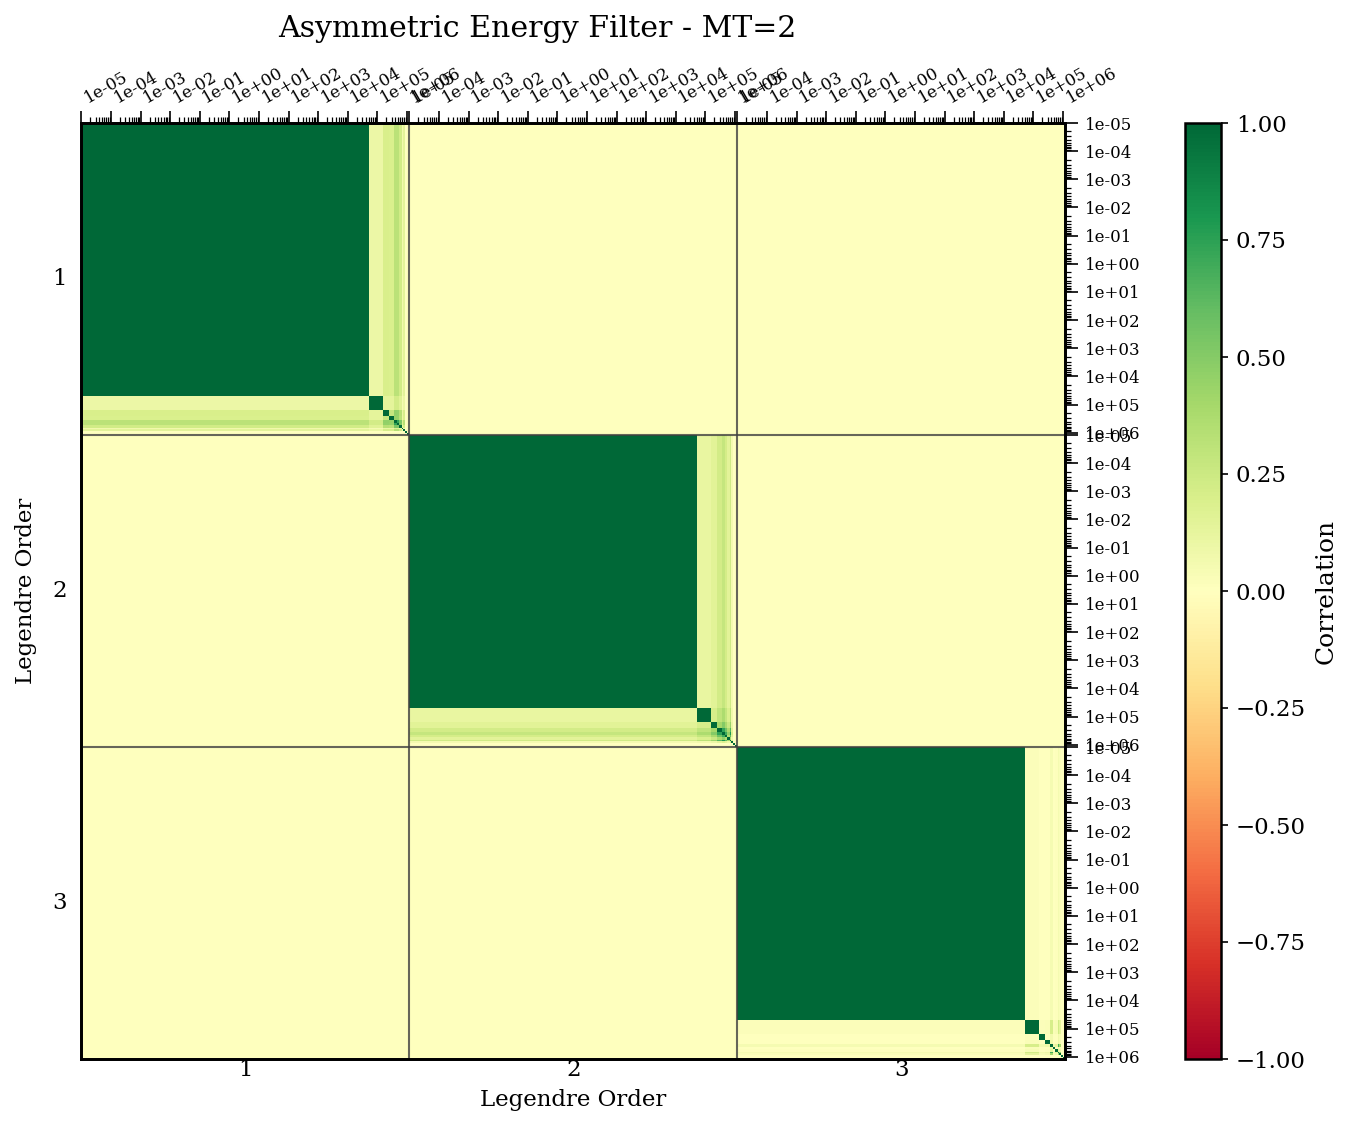


Asymmetric limits show correlation between different energy ranges
Useful for examining cross-correlations between energy regions

Note: Uncertainty panels disabled when using energy filtering on multi-block heatmaps


In [41]:
# Example: Asymmetric energy filtering (different x and y ranges)
# This creates a rectangular zoom showing correlation between different energy ranges
if len(available_l) >= 2:
    fig = (HeatmapBuilder()
           .add_heatmap(heatmap_data_multi, show_uncertainties=False)
           .set_limits(
               x_lim=(1e3, 1e5),   # X-axis: 1 keV to 100 keV
               y_lim=(1e5, 1e6)    # Y-axis: 100 keV to 1 MeV
           )
           .set_labels(
               title=f"Asymmetric Energy Filter - MT={mt_to_plot}"
           )
           .build())
    plt.show()
    
    print("\nAsymmetric limits show correlation between different energy ranges")
    print("Useful for examining cross-correlations between energy regions")
    print("\nNote: Uncertainty panels disabled when using energy filtering on multi-block heatmaps")